# Imports

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as scp
from scipy.cluster.hierarchy import linkage, dendrogram
import statsmodels.api as sm
import statsmodels.stats.multitest as multi

In [2]:
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test, multivariate_logrank_test
from lifelines.plotting import add_at_risk_counts

In [3]:
from matplotlib.pyplot import FormatStrFormatter

In [4]:
import matplotlib.patches as mpatches

In [5]:
# Toggle as needed
import warnings
warnings.filterwarnings("ignore")

# Functions

In [6]:
def response_rate_logit(x,y):
    log_reg = sm.Logit(y,sm.add_constant(x)).fit(method='lbfgs',maxiter=99999,disp=0)
    return log_reg.pvalues,log_reg.params

In [7]:
def survival_curve_pair(df,var_label,durations_label,event_observed_label):
    
    fig=plt.figure(figsize=(6,4))
    ax = fig.add_subplot(111)
    
    med_pfs = []
    df_trim = df.dropna(subset=[var_label,durations_label,event_observed_label])
    df_onehot = pd.get_dummies(df_trim[var_label])
    
    kmf_exp = KaplanMeierFitter()
    df_surv = df_trim[df_trim[var_label]==df_onehot.columns[0]][[durations_label,event_observed_label]]
    ax = kmf_exp.fit(df_surv[durations_label],df_surv[event_observed_label],label=df_onehot.columns[0]).\
            plot_survival_function(ax=ax,show_censors=False,ci_show=False)
    med_pfs.append([var_label,df_onehot.columns[0],kmf_exp.median_survival_time_])
    
    kmf_ctl = KaplanMeierFitter()
    df_surv = df_trim[df_trim[var_label]==df_onehot.columns[1]][[durations_label,event_observed_label]]
    ax = kmf_ctl.fit(df_surv[durations_label],df_surv[event_observed_label],label=df_onehot.columns[1]).\
            plot_survival_function(ax=ax,show_censors=False,ci_show=False)
    
    med_pfs.append([var_label,df_onehot.columns[1],kmf_ctl.median_survival_time_])
    add_at_risk_counts(kmf_exp, kmf_ctl, ax=ax)
    
    return med_pfs, ax

# Read in Data

## Set Paths

In [8]:
# Set this to your source_data directory
source_data_path = "/mnt/digphat/syntheticDataBenchmark/Chuong_pipeline/ExperimentNSCLC/LungCancer_ICB/Source Data/"

In [9]:
source_data_path_clinical = source_data_path + 'Clinical/'
source_data_path_exome = source_data_path + 'Exome/'
source_data_path_rna = source_data_path + 'RNA/'
source_data_path_ref = source_data_path + 'Reference/'
source_data_path_int = source_data_path + 'Integrative/'
source_data_path_out = source_data_path + 'Output/'

## Read in Reference Data

In [10]:
panlung_drivers = pd.read_csv(source_data_path_ref + 'panlung_drivers.txt',sep='\t',header=None).iloc[:,0].to_list()
panlung_amps = pd.read_csv(source_data_path_ref + 'panlung_amps.txt',sep='\t',header=None).iloc[:,0].to_list()
panlung_dels = pd.read_csv(source_data_path_ref + 'panlung_dels.txt',sep='\t',header=None).iloc[:,0].to_list()

## Read in Clinical Data

In [60]:
annot_file = 'Table_S1_Clinical_Annotations.xlsx'
su2c_clinical_ravi = pd.read_excel(source_data_path_clinical + annot_file,skiprows=2)

In [161]:
su2c_clinical.columns.tolist()

['Harmonized_SU2C_RNA_Tumor_Sample_ID_v2',
 'Patient_Smoking_Status',
 'Line_of_Therapy',
 'Harmonized_OS_Event',
 'Patient_Sex',
 'Histology_Harmonized',
 'Agent_PD1_Category',
 'Harmonized_Confirmed_BOR_3_Cat',
 'Harmonized_PFS_Event',
 'Patient_Smoking_Pack_Years_Harmonized',
 'Harmonized_OS_Months',
 'PDL1_TPS',
 'Harmonized_PFS_Months',
 'Patient_Age_at_Diagnosis',
 'Advanced_Diagnosis_Date_Positive',
 'Harmonized_Confirmed_BOR_Bin']

In [12]:
su2c_clinical_extra = pd.read_csv\
    (source_data_path_clinical+'SU2C-MARK_Harmonized_Clinical_Annotations_Supplement_v1.txt',sep='\t')

In [89]:
import sys
parent_path = '/mnt/digphat/syntheticDataBenchmark/Chuong_pipeline'
sys.path.append(parent_path)
from SynOmics.processing.postprocessing import post_masking

un_mask_su2c_clinical = pd.read_csv('../../Data/original_data.csv').iloc[:,0:29]
su2c_clinical = post_masking(un_mask_su2c_clinical)
su2c_clinical = su2c_clinical.rename(columns= {
    'Patient_ID': 'Harmonized_SU2C_RNA_Tumor_Sample_ID_v2'
})

su2c_clinical['Harmonized_Confirmed_BOR_Bin'] = su2c_clinical['Harmonized_Confirmed_BOR_3_Cat'].map({
    'PR/CR': 1, 'CR/PR': 1, 'PR': 1, 'CR': 1,
    'SD': 0, 'PD': 0
})

## Read in RNA Data

In [14]:
su2c_bnmf_harm = pd.read_csv(source_data_path_rna + 'SU2C-MARK_Harmonized_Tumor_Clusters_v1.txt',sep='\t')
su2c_bnmf_harm.head()

,Harmonized_SU2C_RNA_Tumor_Sample_ID_v2,Tumor_cluster,T1_strength,T2_strength,T3_strength,T4_strength,T1_norm,T2_norm,T3_norm,T4_norm
0,SU2CLC-CLE-NIVO10-T1,1,0.154,0.030,0.088,0.000,0.567,0.110,0.323,0.000
1,SU2CLC-CLE-NIVO18-T1,2,0.000,0.375,0.000,0.088,0.000,0.810,0.000,0.190
2,SU2CLC-CLE-NIVO19-T1,1,0.489,0.372,0.132,0.004,0.490,0.374,0.133,0.004
3,SU2CLC-CLE-NIVO2-T1,4,0.000,0.183,0.317,0.505,0.000,0.182,0.316,0.503
4,SU2CLC-CLE-NIVO20-T1,1,0.661,0.068,0.182,0.048,0.689,0.071,0.189,0.050


In [15]:
su2c_ssbnmf_harm = pd.read_csv(source_data_path_rna + 'SU2C-MARK_Harmonized_Integrative_Clusters_v1.txt',sep='\t')
su2c_ssbnmf_harm.head()

,Harmonized_SU2C_RNA_Tumor_Sample_ID_v2,Integrative_cluster,I1_strength,I2_strength,I3_strength,I1_norm,I2_norm,I3_norm
0,SU2CLC-CLE-NIVO10-T1,3,0.107,0.025,0.118,0.428,0.101,0.470
1,SU2CLC-CLE-NIVO18-T1,2,0.020,0.483,0.000,0.040,0.960,0.000
2,SU2CLC-CLE-NIVO19-T1,2,0.000,0.795,0.000,0.000,1.000,0.000
3,SU2CLC-CLE-NIVO2-T1,3,0.006,0.027,0.139,0.036,0.156,0.808
4,SU2CLC-CLE-NIVO20-T1,2,0.000,0.792,0.000,0.000,1.000,0.000


In [105]:
su2c_is_hm_harm_ravi = pd.read_csv(source_data_path_rna + 'SU2C-MARK_Harmonized_Curated_Sets_HM_v1.txt',sep='\t')
su2c_is_hm_harm = pd.read_csv('Signature_analysis/Other_original.csv')
su2c_is_hm_harm = su2c_is_hm_harm.rename(columns = {'Patient_ID':
                                                   'Harmonized_SU2C_RNA_Tumor_Sample_ID_v2'})

In [17]:
su2c_is_dh_harm_ravi = pd.read_csv(source_data_path_rna + 'SU2C-MARK_Harmonized_Curated_Sets_DH_v1.txt',sep='\t')

,Harmonized_SU2C_RNA_Tumor_Sample_ID_v2,B-cells,CD45,CD8 T cells,Cytotoxic cells,DC,Exhausted CD8,Macrophages,Mast cells,Neutrophils,NK CD56dim cells,NK cells,T-cells,Th1 cells,Treg
0,SU2CLC-CLE-NIVO10-T1,-1.206640,-1.168817,-0.312651,-1.818944,-1.751334,-2.229064,-0.770359,-1.133422,-0.629028,-1.843729,-1.627241,-1.332082,-1.610568,-2.223001
1,SU2CLC-CLE-NIVO18-T1,0.219801,0.088713,-0.246769,-0.745221,0.641015,-0.402675,-0.134936,-0.407499,-1.166153,-0.320157,-0.575348,0.312373,-0.036421,0.985207
2,SU2CLC-CLE-NIVO19-T1,0.483138,-0.176360,0.259516,0.160674,0.756281,0.478177,-0.097389,-0.375951,-0.558983,0.786460,-0.463227,0.048374,0.216316,0.538209
3,SU2CLC-CLE-NIVO2-T1,0.206836,0.146816,1.047910,0.444440,0.236922,0.788992,0.614575,-1.097114,0.161120,0.551745,0.556051,0.540561,0.858795,0.002414
4,SU2CLC-CLE-NIVO20-T1,0.610164,0.222164,2.591455,2.203856,-0.176264,2.585199,0.522922,-1.060015,-0.491975,1.089008,1.195594,1.453646,1.429502,1.217274


In [42]:
su2c_is_sf_harm_ravi = pd.read_csv(source_data_path_rna + 'SU2C-MARK_Harmonized_Curated_Sets_SF_v1.txt',sep='\t')
su2c_is_sf_harm = pd.read_csv('Signature_analysis/SF_original.csv')
su2c_is_sf_harm = su2c_is_sf_harm.rename(columns = {'Patient_ID':
                                                   'Harmonized_SU2C_RNA_Tumor_Sample_ID_v2'})
# su2c_is_sf_harm.head()

In [46]:
su2c_is_zi_harm_ravi = pd.read_csv(source_data_path_rna + 'SU2C-MARK_Harmonized_Curated_Sets_ZI_v1.txt',sep='\t')
su2c_is_zi_harm = pd.read_csv('Signature_analysis/ZI_original.csv')
su2c_is_zi_harm = su2c_is_zi_harm.rename(columns = {'Patient_ID':
                                                   'Harmonized_SU2C_RNA_Tumor_Sample_ID_v2'})
# su2c_is_zi_harm.head()

In [21]:
su2c_rna_harm = pd.read_csv(source_data_path_rna + 'SU2C-MARK_Harmonized_rnaseqc_tpm_v1.gct',skiprows=2,sep='\t')
su2c_rna_harm.head()

,Name,Description,SU2CLC-CLE-NIVO10-T1,SU2CLC-CLE-NIVO18-T1,SU2CLC-CLE-NIVO19-T1,SU2CLC-CLE-NIVO2-T1,SU2CLC-CLE-NIVO20-T1,SU2CLC-CLE-NIVO21-T1,SU2CLC-CLE-NIVO24-T1,SU2CLC-CLE-NIVO3-T1,...,SU2CLC-MSK-A2013-T1,SU2CLC-MSK-A2014-T1,SU2CLC-MSK-A2060-T1,SU2CLC-MSK-A2075-T1,SU2CLC-UCD-1124-T1,SU2CLC-UCD-1137-T1,SU2CLC-UCD-1142-T1,SU2CLC-UCD-1143-T1,SU2CLC-UCD-1557-T1,SU2CLC-UCD-1560-T1
0,ENSG00000223972.5,DDX11L1,0.00000,0.0000,0.465325,0.663131,0.038447,0.0000,0.036191,0.083753,...,0.057543,0.009227,0.00000,0.056734,0.018465,0.507545,0.02658,0.236091,0.0000,0.15309
1,ENSG00000227232.5,WASH7P,1.72811,13.2271,17.226100,9.344120,10.023100,44.2401,0.511251,9.400640,...,9.951610,1.315370,1.37496,7.067370,6.450200,5.491240,4.19865,3.714150,55.4283,4.32528
2,ENSG00000278267.1,MIR6859-1,0.00000,0.0000,0.000000,0.000000,0.000000,0.0000,0.000000,0.000000,...,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.00000,0.000000,0.0000,0.00000
3,ENSG00000243485.5,MIR1302-2HG,0.00000,0.0000,0.000000,0.000000,0.000000,0.0000,0.215248,0.000000,...,0.000000,0.000000,0.00000,0.000000,0.188272,0.047259,0.00000,0.000000,0.0000,0.00000
4,ENSG00000284332.1,MIR1302-2,0.00000,0.0000,0.000000,0.000000,0.000000,0.0000,0.000000,0.000000,...,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.00000,0.000000,0.0000,0.00000


In [22]:
su2c_limma_harm = pd.read_csv(source_data_path_rna + 'SU2C-MARK_Harmonized_Limma_All_v1.txt',sep='\t')
su2c_limma_harm.head()

,Unnamed: 0,logFC,AveExpr,t,P.Value,adj.P.Val,B,ensembl_gene_id_version,hgnc_symbol,median_log2tpm,gexp_gt1_percent,gexp_gt1_cat
0,1,-0.403370,1.093088,-1.635074,0.104315,0.403476,-4.315271,ENSG00000187634.11,SAMD11,1.117063,0.785124,50-80%
1,2,0.088979,5.565879,1.021167,0.308964,0.632204,-5.437019,ENSG00000188976.10,NOC2L,5.311830,0.983471,80-100%
2,3,-0.019629,3.103165,-0.153923,0.877896,0.954957,-5.669993,ENSG00000187961.13,KLHL17,3.266475,0.983471,80-100%
3,4,0.194845,2.217655,0.922449,0.357906,0.669481,-5.190195,ENSG00000187583.10,PLEKHN1,2.603013,0.958678,80-100%
4,5,0.110187,-1.277853,0.368140,0.713334,0.883703,-5.027598,ENSG00000187642.9,PERM1,0.504215,0.512397,50-80%


In [23]:
su2c_tme_gsea_harm = pd.read_csv(source_data_path_rna + 'SU2C-MARK_TME_Cluster_GSEA.tsv',sep='\t')

## Merge Data

In [35]:
su2c_merge_master = su2c_clinical.merge(su2c_clinical_extra,\
        left_on='Harmonized_SU2C_Participant_ID_v2',right_on='Harmonized_SU2C_Participant_ID_v2',how='inner')\
    .merge(su2c_val_harm_dam_pv_drivers.rename(columns = lambda x: x+'_MUT'),\
        left_on='Harmonized_SU2C_WES_Tumor_Sample_ID_v2',right_on='Tumor_Sample_Barcode_MUT',how='left').drop('Tumor_Sample_Barcode_MUT',axis=1)\
    .merge(su2c_cnv_gene_sig_t.rename(columns=lambda x: x+'_CNV'),\
        left_on='Harmonized_SU2C_WES_Tumor_Sample_ID_v2',right_index=True,how='left')\
    .merge(su2c_cnv_peak_actual_t,\
        left_on='Harmonized_SU2C_WES_Tumor_Sample_ID_v2',right_index=True,how='left')\
    .merge(su2c_cnv_arm_t,\
        left_on='Harmonized_SU2C_WES_Tumor_Sample_ID_v2',right_index=True,how='left')\
    .merge(su2c_cnv_totals,\
        left_on='Harmonized_SU2C_WES_Tumor_Sample_ID_v2',right_on='Harmonized_SU2C_WES_Tumor_Sample_ID_v2',how='left')\
    .merge(su2c_tmb_sig_tmb_harm,\
        left_on='Harmonized_SU2C_WES_Tumor_Sample_ID_v2',right_on='Harmonized_SU2C_WES_Tumor_Sample_ID_v2',how='left')\
    .merge(su2c_tmb_sig_tmb_harm_log,\
        left_on='Harmonized_SU2C_WES_Tumor_Sample_ID_v2',right_index=True,how='left')\
    .merge(su2c_hla_summary,\
        left_on='Harmonized_SU2C_WES_Tumor_Sample_ID_v2',right_on='Harmonized_SU2C_WES_Tumor_Sample_ID_v2',how='left')\
    .merge(su2c_wes_mixcr_harm,\
        left_on='Harmonized_SU2C_WES_Tumor_Sample_ID_v2',right_on='Harmonized_SU2C_WES_Tumor_Sample_ID_v2',how='left')\
    .merge(su2c_wes_abs_harm,\
          left_on='Harmonized_SU2C_WES_Tumor_Sample_ID_v2',right_on='Harmonized_SU2C_WES_Tumor_Sample_ID_v2',how='left')\
    .merge(su2c_bnmf_harm,\
          left_on='Harmonized_SU2C_RNA_Tumor_Sample_ID_v2',right_on='Harmonized_SU2C_RNA_Tumor_Sample_ID_v2',how='left')\
    .merge(su2c_ssbnmf_harm,\
          left_on='Harmonized_SU2C_RNA_Tumor_Sample_ID_v2',right_on='Harmonized_SU2C_RNA_Tumor_Sample_ID_v2',how='left')\
    .merge(su2c_is_hm_harm.rename(columns = lambda x: x + '_HM'),\
          left_on='Harmonized_SU2C_RNA_Tumor_Sample_ID_v2',right_on='Harmonized_SU2C_RNA_Tumor_Sample_ID_v2_HM',how='left')\
          .drop('Harmonized_SU2C_RNA_Tumor_Sample_ID_v2_HM',axis=1)\
    .merge(su2c_is_dh_harm.rename(columns = lambda x: x + '_DH'),\
          left_on='Harmonized_SU2C_RNA_Tumor_Sample_ID_v2',right_on='Harmonized_SU2C_RNA_Tumor_Sample_ID_v2_DH',how='left')\
          .drop('Harmonized_SU2C_RNA_Tumor_Sample_ID_v2_DH',axis=1)\
    .merge(su2c_is_sf_harm.rename(columns = lambda x: x + '_SF'),\
          left_on='Harmonized_SU2C_RNA_Tumor_Sample_ID_v2',right_on='Harmonized_SU2C_RNA_Tumor_Sample_ID_v2_SF',how='left')\
          .drop('Harmonized_SU2C_RNA_Tumor_Sample_ID_v2_SF',axis=1)\
    .merge(su2c_is_zi_harm.rename(columns = lambda x: x + '_ZI'),\
          left_on='Harmonized_SU2C_RNA_Tumor_Sample_ID_v2',right_on='Harmonized_SU2C_RNA_Tumor_Sample_ID_v2_ZI',how='left')\
          .drop('Harmonized_SU2C_RNA_Tumor_Sample_ID_v2_ZI',axis=1)\
    .merge(su2c_is_zi_ext_harm.rename(columns = lambda x: x + '_ZI'),\
          left_on='Harmonized_SU2C_RNA_Tumor_Sample_ID_v2',right_on='Harmonized_SU2C_RNA_Tumor_Sample_ID_v2_ZI',how='left')\
          .drop('Harmonized_SU2C_RNA_Tumor_Sample_ID_v2_ZI',axis=1)

In [79]:
su2c_merge_master = su2c_clinical_ravi.merge(su2c_clinical_extra,\
        left_on='Harmonized_SU2C_Participant_ID_v2',right_on='Harmonized_SU2C_Participant_ID_v2',how='inner')\
    .merge(su2c_is_hm_harm.rename(columns = lambda x: x + '_HM'),\
          left_on='Harmonized_SU2C_RNA_Tumor_Sample_ID_v2',right_on='Harmonized_SU2C_RNA_Tumor_Sample_ID_v2_HM',how='left')\
          .drop('Harmonized_SU2C_RNA_Tumor_Sample_ID_v2_HM',axis=1)\
    .merge(su2c_is_sf_harm.rename(columns = lambda x: x + '_SF'),\
          left_on='Harmonized_SU2C_RNA_Tumor_Sample_ID_v2',right_on='Harmonized_SU2C_RNA_Tumor_Sample_ID_v2_SF',how='left')\
          .drop('Harmonized_SU2C_RNA_Tumor_Sample_ID_v2_SF',axis=1)\
    .merge(su2c_is_zi_harm.rename(columns = lambda x: x + '_ZI'),\
          left_on='Harmonized_SU2C_RNA_Tumor_Sample_ID_v2',right_on='Harmonized_SU2C_RNA_Tumor_Sample_ID_v2_ZI',how='left')\
          .drop('Harmonized_SU2C_RNA_Tumor_Sample_ID_v2_ZI',axis=1)\
    # .merge(su2c_is_zi_ext_harm.rename(columns = lambda x: x + '_ZI'),\
    #       left_on='Harmonized_SU2C_RNA_Tumor_Sample_ID_v2',right_on='Harmonized_SU2C_RNA_Tumor_Sample_ID_v2_ZI',how='left')\
    #       .drop('Harmonized_SU2C_RNA_Tumor_Sample_ID_v2_ZI',axis=1)

In [80]:
su2c_merge_master.head()

,WES_Cohort_1,WES_Cohort_2,WES_All,RNA_Cohort_1,RNA_Cohort_2,RNA_All,Institution,Harmonized_SU2C_Participant_ID_v2,Harmonized_SU2C_WES_Tumor_Sample_ID_v2,Harmonized_SU2C_WES_Normal_Sample_ID_v2,...,hMø8_ZI,hMø9_ZI,hN1_ZI,hN2_ZI,hN3_ZI,hN5_ZI,hDC1_ZI,hDC2_ZI,hDC3_ZI,hpDC_ZI
0,1.0,NaN,1.0,NaN,NaN,NaN,Cleveland Clinic,SU2CLC-CLE-NIVO1,SU2CLC-CLE-NIVO1-T1,SU2CLC-CLE-NIVO1-N1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,1.0,NaN,1.0,Cleveland Clinic,SU2CLC-CLE-NIVO10,NaN,NaN,...,-0.695905,-0.948536,0.768278,-2.138743,-1.620829,-0.733583,-1.311224,-1.652641,-3.256649,-2.206210
2,1.0,NaN,1.0,1.0,NaN,1.0,Cleveland Clinic,SU2CLC-CLE-NIVO18,SU2CLC-CLE-NIVO18-T1,SU2CLC-CLE-NIVO18-N1,...,-0.504625,-0.168546,-1.716459,0.525149,-0.717704,-0.381993,-0.276729,-1.689989,-0.427555,0.100792
3,1.0,NaN,1.0,1.0,NaN,1.0,Cleveland Clinic,SU2CLC-CLE-NIVO19,SU2CLC-CLE-NIVO19-T1,SU2CLC-CLE-NIVO19-N1,...,-0.122908,1.142965,-0.044152,2.035052,0.416824,-0.651455,-0.022085,0.612891,0.555568,0.741393
4,NaN,NaN,NaN,1.0,NaN,1.0,Cleveland Clinic,SU2CLC-CLE-NIVO2,NaN,NaN,...,2.745711,1.813949,0.449695,0.242486,0.804446,-0.333212,0.308714,0.653263,0.382520,0.940789


In [112]:
su2c_merge_master = su2c_clinical.merge(su2c_is_hm_harm.rename(columns = lambda x: x + '_HM'),\
          left_on='Harmonized_SU2C_RNA_Tumor_Sample_ID_v2',right_on='Harmonized_SU2C_RNA_Tumor_Sample_ID_v2_HM',how='left')\
          .drop('Harmonized_SU2C_RNA_Tumor_Sample_ID_v2_HM',axis=1)\
    .merge(su2c_is_sf_harm.rename(columns = lambda x: x + '_SF'),\
          left_on='Harmonized_SU2C_RNA_Tumor_Sample_ID_v2',right_on='Harmonized_SU2C_RNA_Tumor_Sample_ID_v2_SF',how='left')\
          .drop('Harmonized_SU2C_RNA_Tumor_Sample_ID_v2_SF',axis=1)\
    .merge(su2c_is_zi_harm.rename(columns = lambda x: x + '_ZI'),\
          left_on='Harmonized_SU2C_RNA_Tumor_Sample_ID_v2',right_on='Harmonized_SU2C_RNA_Tumor_Sample_ID_v2_ZI',how='left')\
          .drop('Harmonized_SU2C_RNA_Tumor_Sample_ID_v2_ZI',axis=1)\
    # .merge(su2c_is_zi_ext_harm.rename(columns = lambda x: x + '_ZI'),\
    #       left_on='Harmonized_SU2C_RNA_Tumor_Sample_ID_v2',right_on='Harmonized_SU2C_RNA_Tumor_Sample_ID_v2_ZI',how='left')\
    #       .drop('Harmonized_SU2C_RNA_Tumor_Sample_ID_v2_ZI',axis=1)

# Significance Testing

## Feature List

In [77]:
select_cols = \
['PDL1_TPS'] +\
['B-cells_SF',
 'Cytotoxic cells_SF',
 'DC_SF',
 'Exhausted CD8_SF',
 'Exhausted/HS CD8_SF',
 'Lymphocytes_SF',
 'Lymphocytes exhausted/cell cycle_SF',
 'Macrophages/Monocytes_SF',
 'Memory T cells_SF',
 'Plasma_SF',
 'Treg_SF',
 'hMø1_ZI',
 'hMø4_ZI',
 'hMø5_ZI',
 'hMø6_ZI',
 'hMø7_ZI',
 'hMø8_ZI',
 'hMø9_ZI',
 'hMono1_ZI',
 'hMono2_ZI',
 'hMono3_ZI']+\
['hN1_ZI', 
 'hN2_ZI',
'hN3_ZI',
 'hN5_ZI',
 'hDC1_ZI',
 'hDC2_ZI',
 'hDC3_ZI',
 'hpDC_ZI']

## Logistic Regression Testing

In [114]:
log_reg = []
df = pd.DataFrame()
df_test = su2c_merge_master
for feature in select_cols:
    X = df_test.set_index('Harmonized_SU2C_RNA_Tumor_Sample_ID_v2').loc[:,[feature]]
    if X.iloc[:,0].dtype.name!='float64':
        Xd = pd.get_dummies(X,dummy_na=True).iloc[:,0:-1]
        df = pd.concat([df,Xd],axis=1)
        for col in Xd.columns:
            y = df_test.set_index('Harmonized_SU2C_RNA_Tumor_Sample_ID_v2')['Harmonized_Confirmed_BOR_Bin']
            Xi = Xd[[col]]
            Xy = Xi.merge(y,left_index=True,right_index=True,how='inner').dropna()
            Xi = Xy.iloc[:,[0]]
            y = Xy.iloc[:,[1]]
            p, param = response_rate_logit(Xi,y)
            log_reg.append([Xi.columns[0],p[1],param[1]])
    else:
        df = pd.concat([df,X],axis=1)
        y = df_test.set_index('Harmonized_SU2C_RNA_Tumor_Sample_ID_v2')['Harmonized_Confirmed_BOR_Bin']
        Xy = X.merge(y,left_index=True,right_index=True,how='inner').dropna()
        X = Xy.iloc[:,[0]]
        y = Xy.iloc[:,[1]]
        p, param = response_rate_logit(X,y)
        log_reg.append([feature,p[1],param[1]])
log_reg_df = pd.DataFrame(log_reg,columns=['Feature','p_value','coeff']).set_index('Feature')

In [101]:
log_reg_df['q_value'] = multi.multipletests(log_reg_df['p_value'],method='fdr_bh')[1]

In [36]:
log_reg_df

,p_value,coeff,q_value
Feature,,,
PDL1_TPS,0.000849,1.310186,0.025471
B-cells_SF,0.432520,0.141828,0.682926
Cytotoxic cells_SF,0.335392,0.173623,0.679741
DC_SF,0.079421,-0.320741,0.413185
Exhausted CD8_SF,0.088813,0.307088,0.413185
Exhausted/HS CD8_SF,0.339871,0.173878,0.679741
Lymphocytes_SF,0.413544,0.148705,0.682926
Lymphocytes exhausted/cell cycle_SF,0.203701,0.241015,0.584601
Macrophages/Monocytes_SF,0.023363,-0.460365,0.302473


# Expression Analysis

## Immune Cell Subsets

In [116]:
sf_subsets = ['B-cells_y', 'Cytotoxic cells_y', 'DC_y',
       'Exhausted CD8_y', 'Exhausted/HS CD8', 'Lymphocytes',
       'Lymphocytes exhausted/cell cycle', 'Macrophages/Monocytes',
       'Memory T cells', 'Plasma', 'Treg_y']

In [117]:
df_plot = log_reg_df.loc[su2c_is_sf_harm.columns[1:] + '_SF']

In [118]:
df_plot = df_plot.sort_values('coeff',ascending=False)

In [119]:
sf_cols_rename=['Exhausted CD8+ T-cells (G6)',
                'Regulatory T-cells (G7)',
                'Lymphocytes exhausted/cell-cycle (G11)',
                'Exhausted/HS CD8+ T-cells (G9)',
                'Cytotoxic lymphocytes (G8)',
                'B-cells (G1)',                
                'Lymphocytes (G5)',
                'Plasma cells (G2)',
                'Memory T-cells (G10)',
                'Dendritic cells (G4)',
                'Monocytes/Macrophages (G3)']

In [120]:
# df_plot['Signed log10(q-value)'] = -np.log10(df_plot['q_value'])*\
#     np.sign(df_plot['coeff'])
df_plot['Signed log10(p-value)'] = -np.log10(df_plot['p_value'])*\
    np.sign(df_plot['coeff'])

In [121]:
# df_plot = df_plot.sort_values('Signed log10(q-value)',ascending=False)
df_plot = df_plot.sort_values('Signed log10(p-value)',ascending=False)

In [122]:
df_plot['hue'] = np.sign(df_plot["coeff"])

In [123]:
df_plot.index = sf_cols_rename

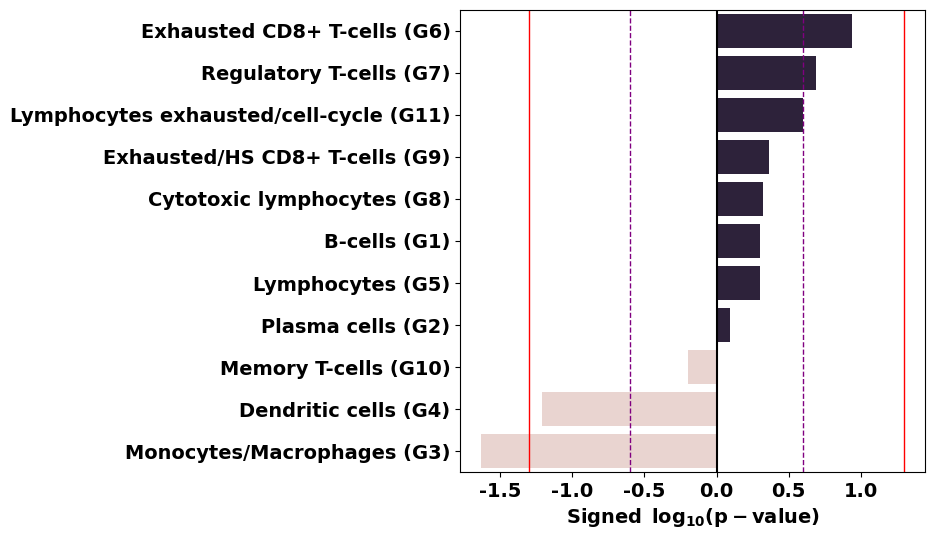

In [127]:
plt.figure(figsize=(6,6))
# h = sns.barplot(y=df_plot.index,x=df_plot['Signed log10(q-value)'],orient='h',\
#                 hue=df_plot['hue'],dodge=False)
h = sns.barplot(y=df_plot.index,x=df_plot['Signed log10(p-value)'],orient='h',\
                hue=df_plot['hue'],dodge=False)
ax=plt.gca()
ymin=ax.get_ylim()[0]
ymax=ax.get_ylim()[1]

plt.vlines(x=0,ymin=ymin,ymax=ymax,colors='k')
ax.axvline(linewidth=1,x=-np.log10(0.05),linestyle='-',c='r')
ax.axvline(linewidth=1,x=-np.log10(0.25),linestyle='dashed',c='purple')
ax.axvline(linewidth=1,x=np.log10(0.05),linestyle='-',c='r')
ax.axvline(linewidth=1,x=np.log10(0.25),linestyle='dashed',c='purple')

plt.ylabel(None)
plt.setp(ax.get_yticklabels(),fontsize=14,weight='bold')
plt.setp(ax.get_xticklabels(), fontsize=12)
plt.ylim(10.5,-0.5)

# plt.xlabel('$\mathregular{Signed\hspace{0.5}log_{10}(q-value)}$',weight='bold',fontsize=14)
plt.xlabel('$\mathregular{Signed\hspace{0.5}log_{10}(p-value)}$',weight='bold',fontsize=14)
ax.set_xticklabels(ax.get_xticks(),weight='bold',fontsize=14)
h.legend_.remove()

## M Cluster Signatures

<Figure size 1400x800 with 0 Axes>

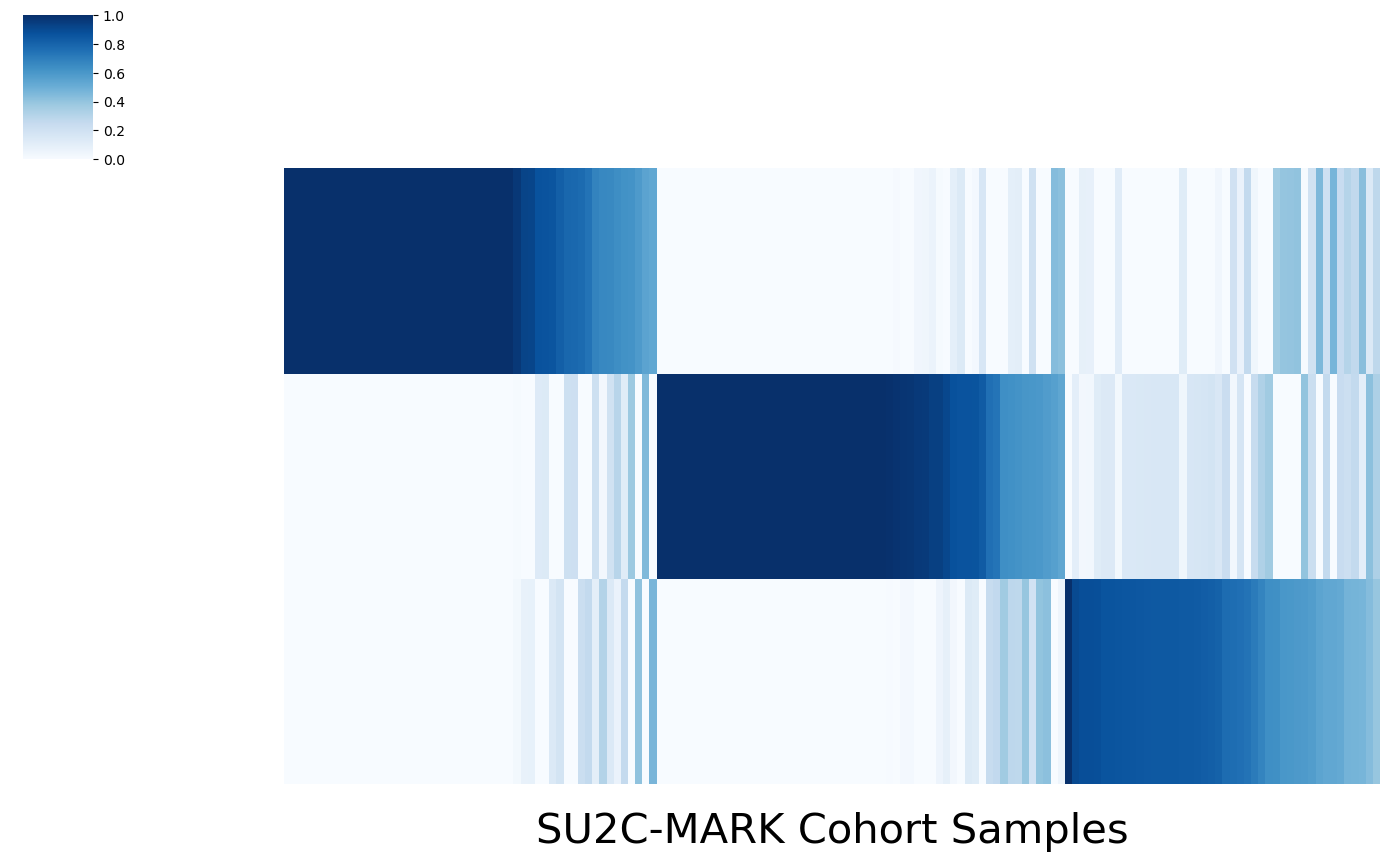

In [67]:
su2c_ssbnmf_harm = su2c_ssbnmf_harm.sort_values(by=['Integrative_cluster'])
su2c_ssbnmf_harm_sorted_I1 = su2c_ssbnmf_harm[su2c_ssbnmf_harm['Integrative_cluster']==1].sort_values(by='I1_norm',\
                                                                ascending=False)
su2c_ssbnmf_harm_sorted_I2 = su2c_ssbnmf_harm[su2c_ssbnmf_harm['Integrative_cluster']==2].sort_values(by='I2_norm',\
                                                                ascending=False)
su2c_ssbnmf_harm_sorted_I3 = su2c_ssbnmf_harm[su2c_ssbnmf_harm['Integrative_cluster']==3].sort_values(by='I3_norm',\
                                                                ascending=False)
su2c_ssbnmf_harm_sorted = pd.concat([su2c_ssbnmf_harm_sorted_I1,su2c_ssbnmf_harm_sorted_I2,\
          su2c_ssbnmf_harm_sorted_I3])
plt.figure(figsize=(14,8))
g = sns.clustermap(su2c_ssbnmf_harm_sorted[['I1_norm','I2_norm','I3_norm']].T,vmin=0,vmax=1,cmap='Blues',\
            yticklabels=False,xticklabels=False,row_cluster=False,col_cluster=False,\
               cbar_kws={'ticks':None,'label':None},figsize=(14,8))
_=g.ax_heatmap.set_xlabel('SU2C-MARK Cohort Samples',fontsize=30,labelpad=20)

## Gene Set Enrichment Results for M Clusters

In [68]:
su2c_tme_gsea_harm['-log10(p-value)'] = -np.log10(su2c_tme_gsea_harm['p-value'])

In [69]:
su2c_tme_gsea_harm_pivot = pd.pivot_table(su2c_tme_gsea_harm[['Gene Set Name','Set','-log10(p-value)']],\
                    index='Set',values='-log10(p-value)',columns='Gene Set Name').fillna(0).T
su2c_tme_gsea_harm_pivot_sorted =su2c_tme_gsea_harm_pivot.sort_values(by=['G1','G2','G3'],ascending=False)

In [70]:
su2c_tme_gsea_harm['Gene Set Name Short'] = su2c_tme_gsea_harm['Gene Set Name'].apply(lambda x: x.replace('HALLMARK_',''))

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

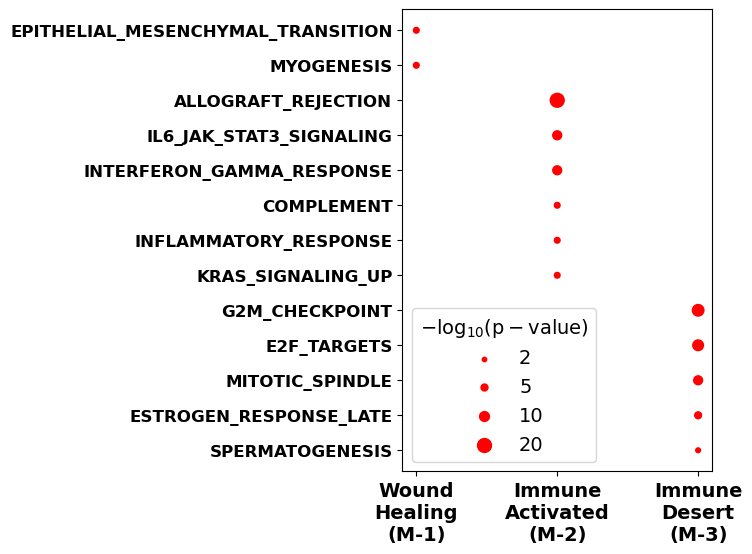

In [71]:
plt.figure(figsize=(4,6))

g = plt.scatter(data = su2c_tme_gsea_harm,x = 'Set',y = 'Gene Set Name Short',\
           color='r',vmin=0,vmax=5,s=su2c_tme_gsea_harm['-log10(p-value)']*5)

plt.gca().invert_yaxis()

ax = plt.gca()
ax.set_xticklabels(['Wound\nHealing\n(M-1)','Immune\nActivated\n(M-2)','Immune\nDesert\n(M-3)'])
plt.ylabel(None)
_ = plt.setp(ax.get_yticklabels(), font = 'Arial',fontsize=12,weight='bold')
plt.xlabel(None)
_ = plt.setp(ax.get_xticklabels(),font = 'Arial',fontsize=14,weight='bold')

msizes = [2, 5, 10, 20]
markers = []
for size in msizes:
   markers.append(plt.scatter([],[], s=size*5, label=size, color='r'))

_=plt.legend(handles=markers,title = "$\mathregular{-log_{10}(p-value)}$",title_fontsize=14,fontsize=14,loc='lower left')

## Response Rate by M Cluster

In [72]:
I_cluster_response = su2c_merge_master[['Integrative_cluster','Harmonized_Confirmed_BOR_Bin']]\
    .groupby(by=['Integrative_cluster','Harmonized_Confirmed_BOR_Bin']).size().reset_index().\
    sort_values(['Integrative_cluster','Harmonized_Confirmed_BOR_Bin'])

In [73]:
I_cluster_response['Response']= ['Non-responder','Responder']*3

In [74]:
a = I_cluster_response.pivot_table(index='Integrative_cluster',values=0,columns='Response')
a_norm = a.apply(lambda x: x/x.sum(),axis=1)

In [75]:
tab10 = sns.color_palette('tab10')

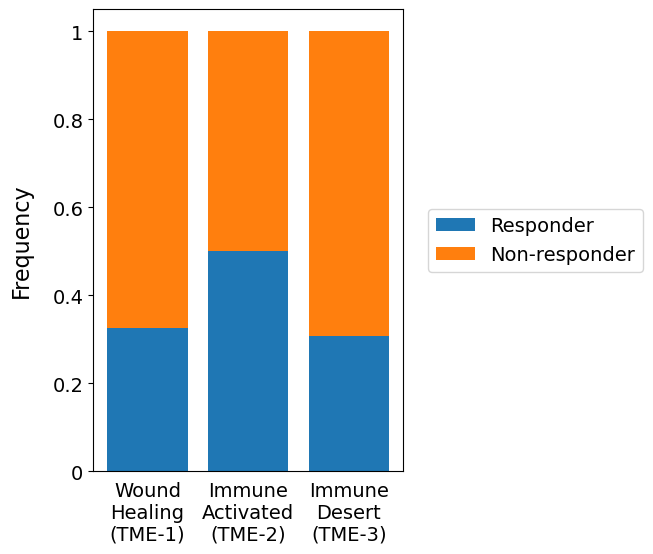

In [76]:
plt.figure(figsize=(4,6))
plt.bar(a_norm.index,a_norm['Responder'],color=tab10[0],label = 'Responder')
plt.bar(a_norm.index,a_norm['Non-responder'],color=tab10[1],bottom = a_norm['Responder'],label='Non-responder')
plt.legend(loc='center left',bbox_to_anchor=(1.05,0.5),ncol=1,fontsize=14)
g = plt.gca()
g.set_xticklabels(['','','Wound\nHealing\n(TME-1)','','Immune\nActivated\n(TME-2)','','Immune\nDesert\n(TME-3)'],fontsize=14)
g.set_yticklabels([0,0.2,0.4,0.6,0.8,1],fontsize=14)
g.tick_params(bottom=False)
_=g.set_ylabel('Frequency',fontsize=16,labelpad = 14)

## Immune Cell Subsets by M Cluster

In [77]:
sf_subsets = [col for col in su2c_merge_master.columns if '_SF' in col][1:]

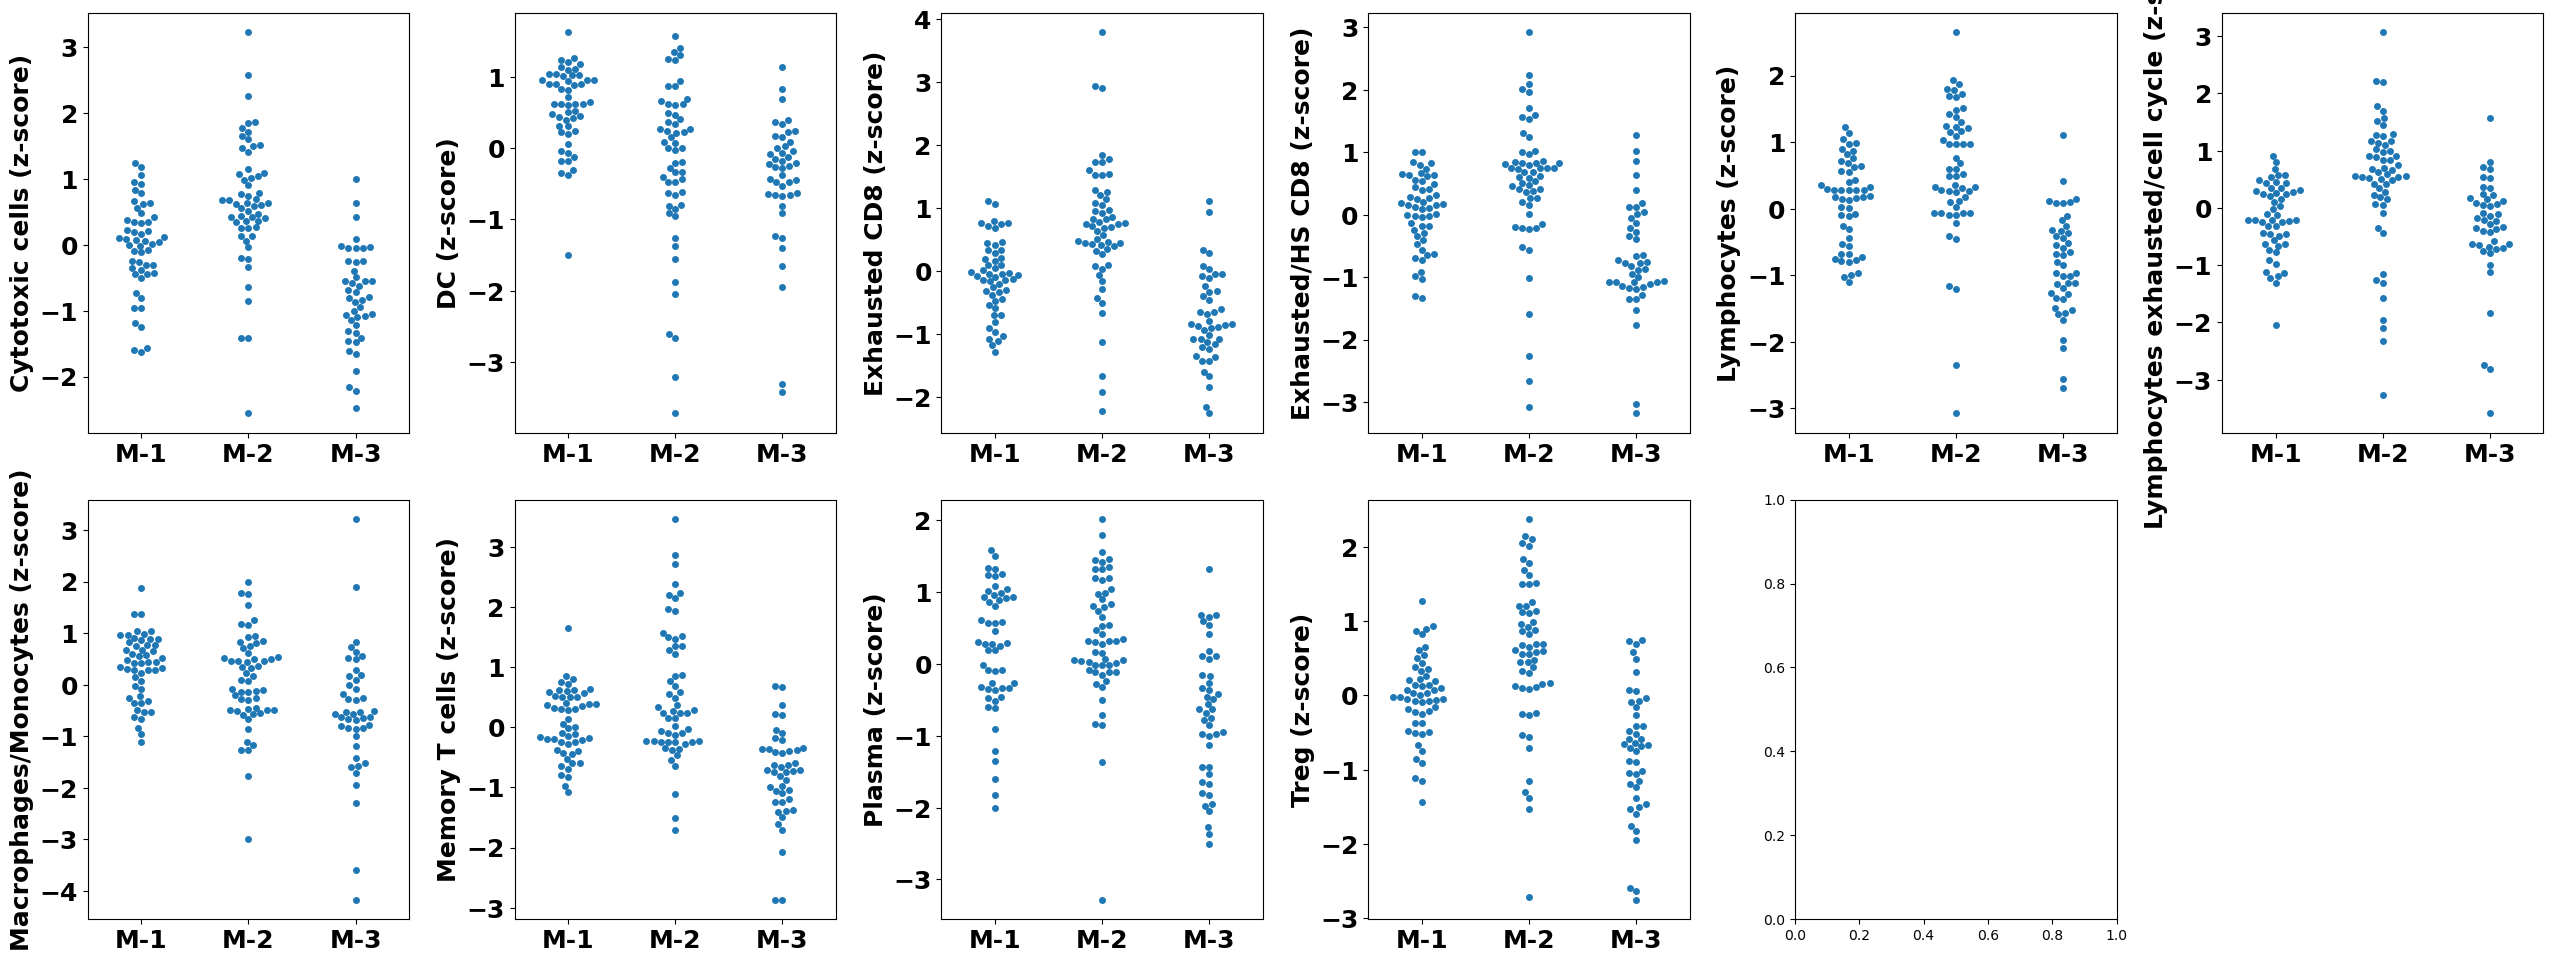

In [78]:
rows = 2
cols = 6
zi_cols = sf_subsets

fig,axs = plt.subplots(rows,cols,figsize=(26,10))

for i in range(0,len(zi_cols)):
    row = int(np.floor(i/cols))
    col = i%cols
    subset = zi_cols[i]
    g = sns.swarmplot(data=su2c_merge_master,x='Integrative_cluster',\
                   y=subset,ax=axs[row,col])
    g.set_xticklabels(['M-1','M-2','M-3'],fontsize=14)
    g.set_ylabel(g.get_ylabel().split('_')[0]+' (z-score)',fontsize=16)
    df = su2c_merge_master[[subset,'Integrative_cluster']].dropna()
    x = df[df.iloc[:,1]==1].iloc[:,0]
    y = df[df.iloc[:,1]==2].iloc[:,0]
    z = df[df.iloc[:,1]==3].iloc[:,0]
    ax = axs[row,col]
    plt.setp(ax.get_xticklabels(), fontsize=18, weight='bold')
    plt.setp(ax.get_yticklabels(), fontsize=18, weight='bold')
    ax.set_xlabel(None)
    ax.set_ylabel(ax.get_ylabel(),fontsize=18,weight='bold')

fig.tight_layout(pad=2)
fig.delaxes(axs[1][5])

## Myeloid Subsets

In [128]:
mphage_subsets = ['hMø1','hMø4', 'hMø5', 'hMø6', 'hMø7', 'hMø8', 'hMø9', 'hMono1', 'hMono2',
       'hMono3', 'hN1', 'hN2', 'hN3', 'hN5', 'hDC1', 'hDC2', 'hDC3', 'hpDC']

In [129]:
df_plot = log_reg_df.loc[[name + '_ZI' for name in mphage_subsets]]

In [130]:
df_plot = df_plot.sort_values('coeff',ascending=False)

In [131]:
# df_plot['Signed log10(q-value)'] = -np.log10(df_plot['q_value'])*\
#     np.sign(df_plot['coeff'])

df_plot['Signed log10(p-value)'] = -np.log10(df_plot['p_value'])*\
    np.sign(df_plot['coeff'])

In [132]:
# df_plot = df_plot.sort_values('Signed log10(q-value)',ascending=False)
df_plot = df_plot.sort_values('Signed log10(p-value)',ascending=False)

In [133]:
df_plot['hue'] = np.sign(df_plot["coeff"])

In [134]:
df_plot.index = [name.split('_')[0] for name in df_plot.index]

In [135]:
df_plot = df_plot.loc[['hMono2','hMono1','hMono3','hMø1', 'hMø9', 'hMø6', 'hMø4','hMø5','hMø8','hMø7','hN2','hN1',  'hN5',  'hN3','hDC2', 'hDC1',  'hpDC', 
       'hDC3']]

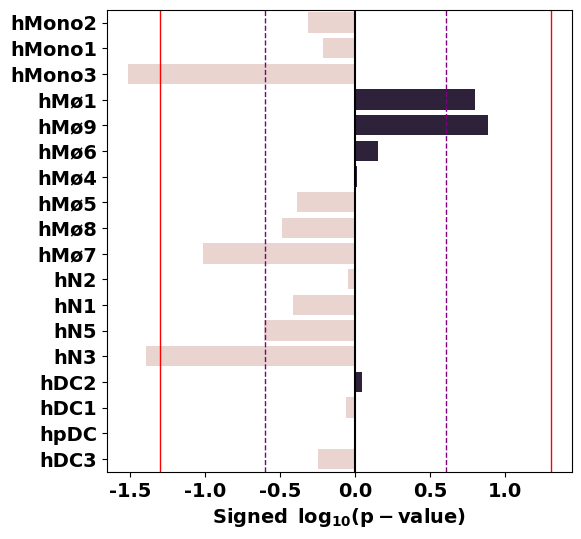

In [136]:
plt.figure(figsize=(6,6))
# h = sns.barplot(y=df_plot.index,x=df_plot['Signed log10(q-value)'],orient='h',\
#                 hue=df_plot['hue'],dodge=False)
h = sns.barplot(y=df_plot.index,x=df_plot['Signed log10(p-value)'],orient='h',\
                hue=df_plot['hue'],dodge=False)
ax=plt.gca()
ymin=ax.get_ylim()[0]
ymax=ax.get_ylim()[1]

plt.vlines(x=0,ymin=ymin,ymax=ymax,colors='k')
ax.axvline(linewidth=1,x=-np.log10(0.05),linestyle='-',c='r')
ax.axvline(linewidth=1,x=-np.log10(0.25),linestyle='dashed',c='purple')
ax.axvline(linewidth=1,x=np.log10(0.05),linestyle='-',c='r')
ax.axvline(linewidth=1,x=np.log10(0.25),linestyle='dashed',c='purple')

plt.ylabel(None)
plt.setp(ax.get_yticklabels(),fontsize=14,weight='bold')
plt.setp(ax.get_xticklabels(), fontsize=12)
plt.ylim(17.5,-0.5)

# plt.xlabel('$\mathregular{Signed\hspace{0.5}log_{10}(q-value)}$',weight='bold',fontsize=14)
plt.xlabel('$\mathregular{Signed\hspace{0.5}log_{10}(p-value)}$',weight='bold',fontsize=14)
ax.set_xticklabels(ax.get_xticks(),weight='bold',fontsize=14)
h.legend_.remove()

## Myeloid Subsets by M Cluster

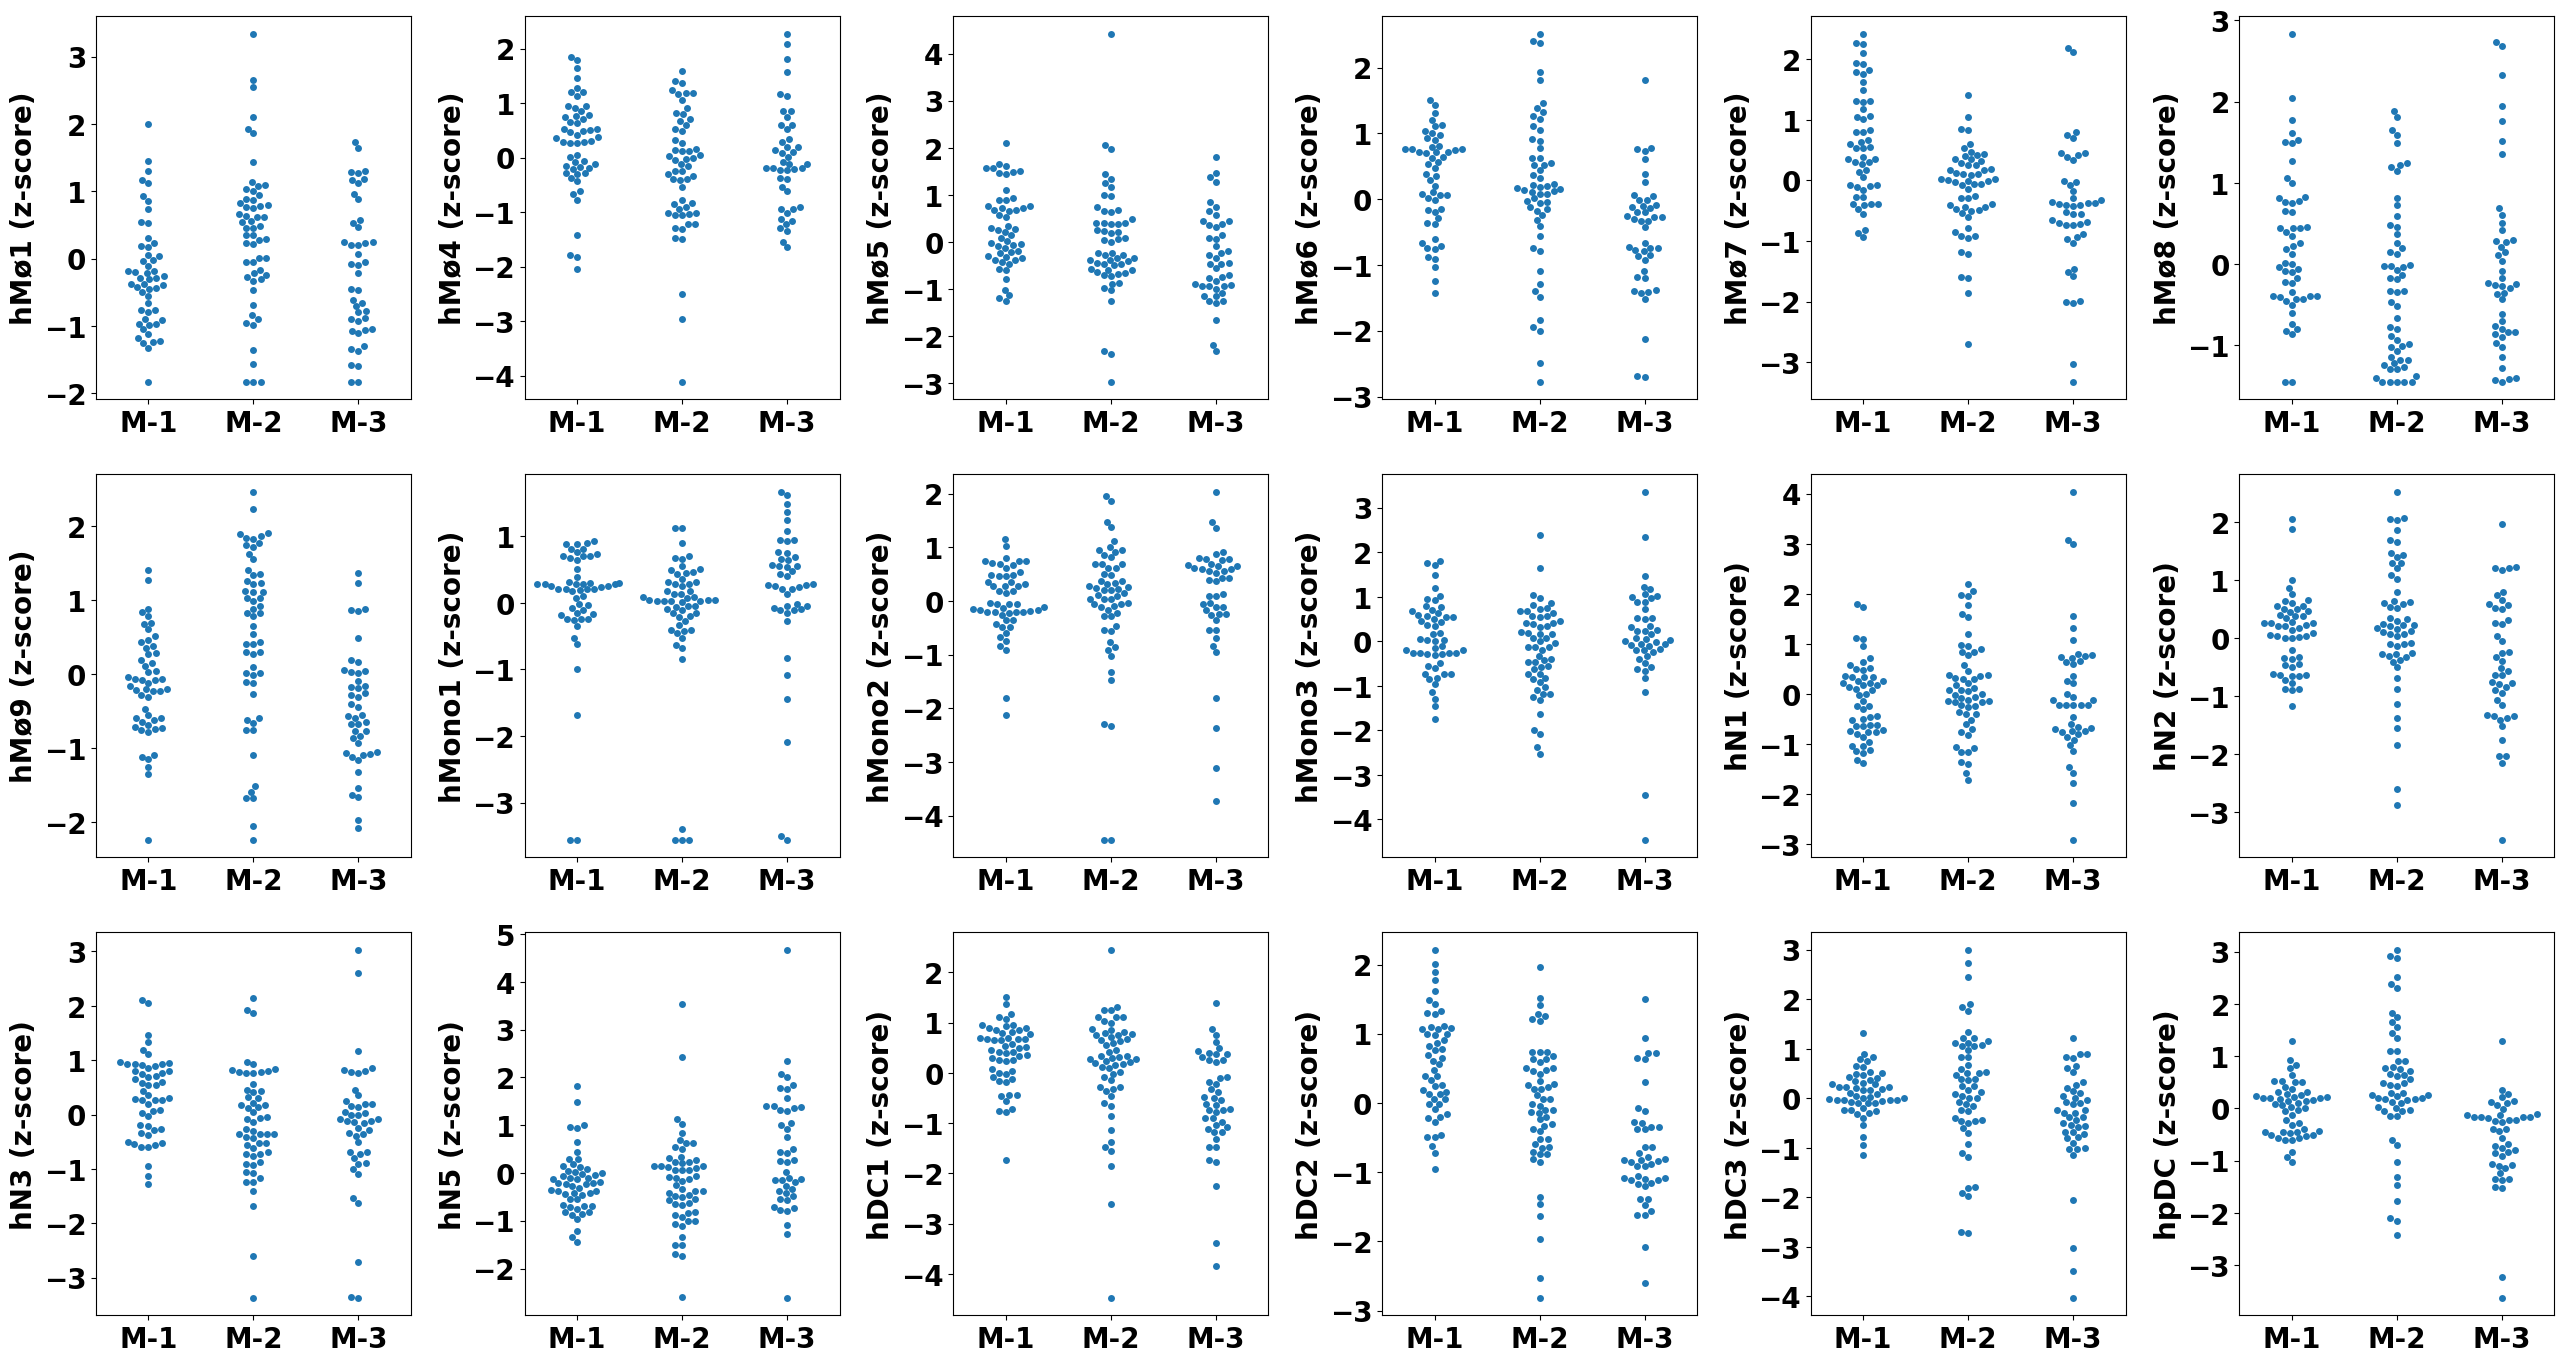

In [88]:
rows = 3
cols = 6
zi_cols = [col +'_ZI' for col in mphage_subsets]

fig,axs = plt.subplots(rows,cols,figsize=(26,14))

for i in range(0,len(zi_cols)):
    row = int(np.floor(i/cols))
    col = i%cols
    subset = zi_cols[i]
    
    g = sns.swarmplot(data=su2c_merge_master,x='Integrative_cluster',\
                   y=subset,ax=axs[row,col])
    g.set_xticklabels(['M-1','M-2','M-3'],fontsize=18)
    g.set_ylabel(g.get_ylabel().split('_')[0]+' (z-score)',fontsize=18)
    
    df = su2c_merge_master[[subset,'Integrative_cluster']].dropna()
    x = df[df.iloc[:,1]==1].iloc[:,0]
    y = df[df.iloc[:,1]==2].iloc[:,0]
    z = df[df.iloc[:,1]==3].iloc[:,0]
    
    ax = axs[row,col]
    plt.setp(ax.get_xticklabels(), fontsize=20, weight='bold')
    plt.setp(ax.get_yticklabels(), fontsize=20, weight='bold')
    ax.set_xlabel(None)
    ax.set_ylabel(ax.get_ylabel(),fontsize=20,weight='bold')
    
fig.tight_layout(pad=2)

## TI Clusters

In [89]:
df_plot = log_reg_df.loc[['T1_norm','T2_norm','T3_norm','T4_norm']]

In [90]:
df_plot = df_plot.sort_values('coeff',ascending=False)

In [91]:
df_plot['Signed log10(q-value)'] = -np.log10(df_plot['q_value'])*\
    np.sign(df_plot['coeff'])

In [92]:
df_plot = df_plot.sort_values('Signed log10(q-value)',ascending=False)

In [93]:
df_plot['hue'] = np.sign(df_plot["coeff"])

In [94]:
df_plot.index = ['TI-1','TI-2','TI-3','TI-4']

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

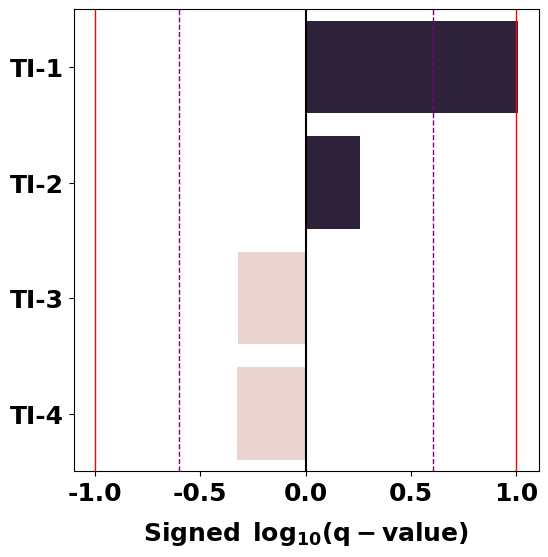

In [95]:
plt.figure(figsize=(6,6))
h = sns.barplot(y=df_plot.index,x=df_plot['Signed log10(q-value)'],orient='h',\
                hue=df_plot['hue'],dodge=False)

ax=plt.gca()
ymin=ax.get_ylim()[0]
ymax=ax.get_ylim()[1]

plt.vlines(x=0,ymin=ymin,ymax=ymax,colors='k')
ax.axvline(linewidth=1,x=-np.log10(0.1),linestyle='-',c='r')
ax.axvline(linewidth=1,x=-np.log10(0.25),linestyle='dashed',c='purple')
ax.axvline(linewidth=1,x=np.log10(0.1),linestyle='-',c='r')
ax.axvline(linewidth=1,x=np.log10(0.25),linestyle='dashed',c='purple')

plt.ylabel(None)
plt.xticks([-1,-0.5,0,0.5,1])
plt.setp(ax.get_yticklabels(), font = 'Arial',fontsize=18,weight='bold')
plt.setp(ax.get_xticklabels(), fontsize=18)
plt.ylim(3.5,-0.5)
            
plt.xlabel('$\mathregular{Signed\hspace{0.5}log_{10}(q-value)}$',weight='bold',fontsize=18,labelpad=10)

ax.set_xticklabels(ax.get_xticks(),font='Arial',weight='bold',fontsize=18)
h.legend_.remove()

## M Clusters vs TI Clusters

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

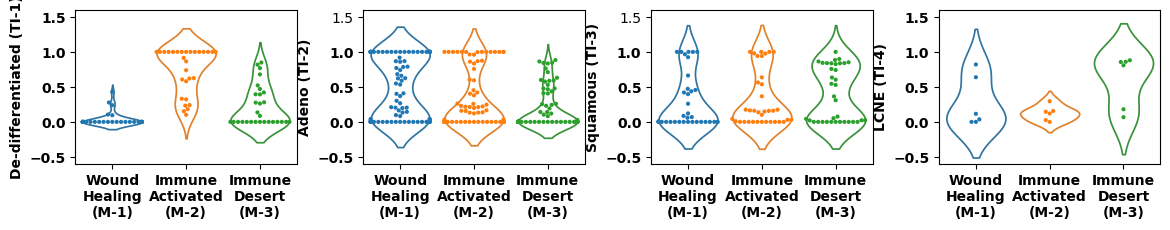

In [96]:
fig,ax = plt.subplots(1,4,figsize=(14,2))

ylabels = ['De-differentiated (TI-1)','Adeno (TI-2)','Squamous (TI-3)','LCNE (TI-4)']
xlabels = ['Wound\nHealing\n(M-1)','Immune\nActivated\n(M-2)','Immune\nDesert\n(M-3)']
for tc in [1,2,3,4]:
    axis = sns.violinplot(data = su2c_merge_master[su2c_merge_master['Tumor_cluster']==tc][['I1_norm','I2_norm','I3_norm']]\
                          ,ax=ax[tc-1],inner=None)
    
    for violin in axis.collections:
        violin.set_edgecolor(violin.get_facecolor())
        violin.set_facecolor((0,0,0,0))

    g = sns.swarmplot(data = su2c_merge_master[su2c_merge_master['Tumor_cluster']==tc][['I1_norm','I2_norm','I3_norm']],\
                   s=3,ax=ax[tc-1])

    plt.setp(ax[tc-1].get_yticklabels(), font = 'Arial',fontsize=10,weight='bold')
    plt.setp(ax[tc-1].get_xticklabels(), fontsize=14)
    ax[tc-1].set_ylim(-0.6,1.6)
    ax[tc-1].set_ylabel(ylabels[tc-1],font='Arial',weight='bold',fontsize=10,\
                        rotation=90)
            
    ax[tc-1].set_xticklabels(xlabels,font='Arial',weight='bold',fontsize=10)
    #plt.yticks([0,0.5,1],[0.0,0.5,1.0])

plt.subplots_adjust(wspace=0.3)

## TI-1 vs M-2

Text(0, 0.5, 'Immune Activated (M-2)')

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

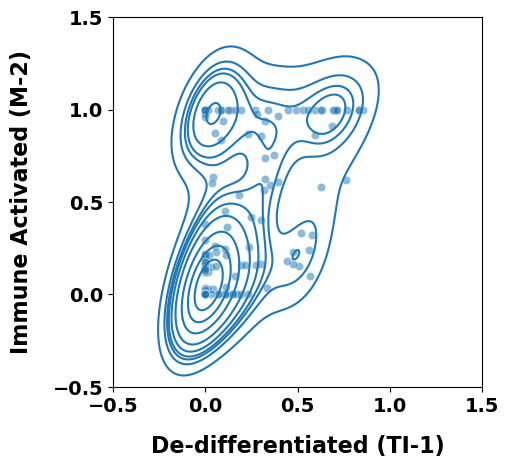

In [97]:
_ = sns.kdeplot(data = su2c_merge_master, x='T1_norm',y='I2_norm')
_ = sns.scatterplot(data = su2c_merge_master, x='T1_norm',y='I2_norm',alpha = 0.5)

plt.axis('square')
plt.xlim(-0.5,1.5)
plt.ylim(-.5,1.5)

ax = plt.gca()

plt.setp(ax.get_yticklabels(), font = 'Arial',fontsize=14,weight='bold')
plt.setp(ax.get_xticklabels(), font = 'Arial',fontsize=14,weight='bold')

ax.xaxis.set_major_locator(plt.MaxNLocator(4))
ax.yaxis.set_major_locator(plt.MaxNLocator(4))

ax.set_xlabel("De-differentiated (TI-1)",font='Arial',weight='bold',fontsize=16,labelpad=14)
ax.set_ylabel("Immune Activated (M-2)",font='Arial',weight='bold',fontsize=16,labelpad=14)

## Response Rate Grid

In [98]:
a = su2c_merge_master[(su2c_merge_master['T1_norm']<0.5) & (su2c_merge_master['I2_norm']<0.5)]['Harmonized_Confirmed_BOR_Bin'].mean()

In [99]:
b = su2c_merge_master[(su2c_merge_master['T1_norm']>=0.5) & (su2c_merge_master['I2_norm']<0.5)]['Harmonized_Confirmed_BOR_Bin'].mean()

In [100]:
c = su2c_merge_master[(su2c_merge_master['T1_norm']<0.5) & (su2c_merge_master['I2_norm']>=0.5)]['Harmonized_Confirmed_BOR_Bin'].mean()

In [101]:
d = su2c_merge_master[(su2c_merge_master['T1_norm']>=0.5) & (su2c_merge_master['I2_norm']>=0.5)]['Harmonized_Confirmed_BOR_Bin'].mean()

In [102]:
rr_df = pd.DataFrame([[c,d],[a,b]],index=['TME-2','TME-2/3/4'],columns=['TI-2/3/4','TI-1'])

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

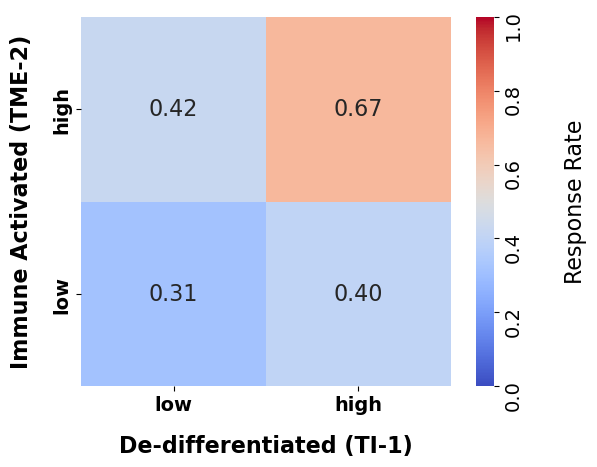

In [103]:
k = sns.heatmap(rr_df,cmap='coolwarm',center=0.5,vmin=0,vmax=1,square='equal',annot=True,fmt="0.2f",annot_kws={"font":'Arial',"size":16})

ax = plt.gca()

plt.setp(ax.get_yticklabels(), font = 'Arial',fontsize=14,weight='bold')
plt.setp(ax.get_xticklabels(), font = 'Arial',fontsize=14,weight='bold')

k.set_xticklabels(labels=['low','high'], va='center')
k.set_yticklabels(labels=['high','low'], va='center')

ax.tick_params(axis='x', which='major', pad=10)

_ = ax.set_xlabel("De-differentiated (TI-1)",font='Arial',weight='bold',fontsize=16,labelpad=14)
_ = ax.set_ylabel("Immune Activated (TME-2)",font='Arial',weight='bold',fontsize=16,labelpad=14)

cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=14,rotation=90)
_ = cbar.ax.set_ylabel("Response Rate",rotation=90,labelpad=30,font='Arial',fontsize=16)

# Heatmap

In [201]:
su2c_limma_harm_names_mine = pd.read_csv('../DGE/CRPR_PD/Seed_42/DGE_Origin.csv')
su2c_limma_harm_names_mine.head()

,Gene,P_value,Log2FC,Q_value,Status
0,WASH7P,0.342165,-0.276118,0.984665,ok
1,RP11-34P13.15,0.212839,0.076892,0.981498,ok
2,RP11-34P13.16,0.081600,0.025416,0.981498,ok
3,ABC7-43046700E7.1,0.853463,0.009943,0.996584,ok
4,RP11-34P13.18,0.624116,-0.080051,0.990808,ok


In [215]:
expression_data = pd.read_csv('../../Data/original_data.csv', index_col = 0).iloc[:,28:]
expression_data = expression_data.T

In [216]:
expression_data_log = expression_data.apply(lambda x: np.log(x+1))

In [220]:
expression_data_log_norm = expression_data_log.T.apply(scp.zscore).T

In [231]:
ravi_genes = ['NHSL2', 'SLC27A3', 'SIPA1L2','AUTS2','TCF7L1','PRPF40A',
             'PSMB9','PSME1','PSME2', 'VGF']

expression_data_log_norm_selected = expression_data_log_norm.loc[ravi_genes]

su2c_rna_harm_log_merge_mine = expression_data_log_norm_selected.T.merge(su2c_merge_master,left_index=True,right_on='Harmonized_SU2C_RNA_Tumor_Sample_ID_v2',how='left')

In [237]:
su2c_rna_harm_log_merge_mine.set_index('Harmonized_SU2C_RNA_Tumor_Sample_ID_v2',inplace=True)

In [303]:
q_near_sig_list = ['PDL1_TPS', 'Macrophages/Monocytes_SF', 'hMono3_ZI','hN3_ZI']
select_cols = ['hMono3_ZI', 'hN3_ZI',
       'Macrophages/Monocytes_SF', 'Adenosine (Corvus) (Willingham et al.)_HM',
       'NHSL2', 'EMT2 (PMID: 27321955)_HM',
       'TGF-B (Mariathasan Nature 2018)_HM', 'SLC27A3',
       'NFAT/NR4A1 family T cell dysfunction_HM', 'SIPA1L2',
       'AUTS2', 'TCF7L1',
       'PRPF40A',
       'Merck/Nanostring 18 gene\xa0T cell–inflamed GEP score_HM',
       'PSMB9',
       'Antigen processing machinery (PMID: 27855702)_HM', 'IFNG_HM',
       'PSME1', 'PSME2', 'PDL1_TPS', 'VGF']

su2c_heatmap_mine = su2c_rna_harm_log_merge_mine[select_cols].corr().fillna(0)
su2c_heatmap_renamed_mine = su2c_heatmap_mine.copy()

In [305]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.cluster.hierarchy import dendrogram

# ---- OPTIONAL: pretty labels for display ----
rename_map = {
    # Wound healing (examples)
    "hMono3_ZI": "hMono3 (Zilionas et al.)",
    "hN3_ZI": "hN3 (Zilionas et al.)",
    "Macrophages/Monocytes_SF": r"M$\phi$\Monocyte (Sade-Feldman et al.)",
    "Adenosine (Corvus) (Willingham et al.)_HM": "A2AR (Willingham et al.)",
    "NHSL2": r"$\it{NHSL2}$ Expression",
    "EMT2 (PMID: 27321955)_HM": "EMT (Hedegaard et al.)",
    "TGF-B (Mariathasan Nature 2018)_HM": "TGF-B (Mariathasan et al.)",
    "SLC27A3": r"$\it{SLC27A3}$ Expression",
    "NFAT/NR4A1 family T cell dysfunction_HM": "NR4A1 (Chen et al.)",
    "SIPA1L2": r"$\it{SIPA1L2}$ Expression",
    "AUTS2": r"$\it{AUTS2}$ Expression",
    "TCF7L1": r"$\it{TCF7L1}$ Expression",

    # Immune activation
    "PRPF40A": r"$\it{PRPF40A}$ Expression",
    "Merck/Nanostring 18 gene\xa0T cell–inflamed GEP score_HM": "T cell–inflamed (Ayers et al.)",
    "PSMB9": r"$\it{PSMB9}$ Expression",
    "Antigen processing machinery (PMID: 27855702)_HM": "MHC Class I (Senbabaoglu et al.)",
    "IFNG_HM": "IFNG Signature (Gao et al.)",
    "PSME1": r"$\it{PSME1}$ Expression",
    "PSME2": r"$\it{PSME2}$ Expression",
    "PDL1_TPS": "PDL1 TPS",

    # Other
    "VGF": r"$\it{VGF}$ Expression",
}

# ---- Define groups as sets of ORIGINAL feature names (before renaming) ----
wound_healing = {
    "hMono3_ZI", "hN3_ZI", "Macrophages/Monocytes_SF", "Adenosine (Corvus) (Willingham et al.)_HM",
    "NHSL2", "EMT2 (PMID: 27321955)_HM", "TGF-B (Mariathasan Nature 2018)_HM",
    "SLC27A3", "NFAT/NR4A1 family T cell dysfunction_HM", "SIPA1L2",
    "AUTS2", "TCF7L1",
}

immune_activation = {
    "PRPF40A", "Merck/Nanostring 18 gene\xa0T cell–inflamed GEP score_HM", "PSMB9",
    "Antigen processing machinery (PMID: 27855702)_HM", "IFNG_HM",
    "PSME1", "PSME2", "PDL1_TPS",
}

other = {"VGF"}

positive = set(immune_activation) | {"VGF"}  # per your spec
negative = set(wound_healing)                # per your spec

In [306]:
def build_two_color_layers(corr_df: pd.DataFrame):
    cols = corr_df.columns

    # Layer 1: Category colors
    pal_cat = {
        "Wound healing": "#7B1FA2",        # tím (purple)
        "Immune activation": "#FB8C00",    # cam (orange)
        "Other": "#9E9E9E",                # xám (tuỳ chọn)
        "Unassigned": "#BDBDBD",           # xám nhạt
    }
    
    # Layer 2: Association colors
    pal_assoc = {
        "Positive": "#1B5E20",             # xanh lá đậm (dark green)
        "Negative": "#C62828",             # đỏ (red)
        "Unassigned": "#BDBDBD",           # xám nhạt
    }

    cat_label = {}
    for c in cols:
        if c in wound_healing:
            cat_label[c] = "Wound healing"
        elif c in immune_activation:
            cat_label[c] = "Immune activation"
        elif c in other:
            cat_label[c] = "Other"
        else:
            cat_label[c] = "Unassigned"

    color_layer_category = pd.Series(
        {c: pal_cat[cat_label[c]] for c in cols},
        index=cols,
        name="Category"
    )


    assoc_label = {}
    for c in cols:
        if c in positive:
            assoc_label[c] = "Positive"
        elif c in negative:
            assoc_label[c] = "Negative"
        else:
            assoc_label[c] = "Unassigned"

    color_layer_assoc = pd.Series(
        {c: pal_assoc[assoc_label[c]] for c in cols},
        index=cols,
        name="Association"
    )

    return color_layer_category, color_layer_assoc, pal_cat, pal_assoc, cat_label, assoc_label

In [307]:
def plot_corr_heatmap_with_two_layers(
    corr_df: pd.DataFrame,
    rename_map = None,
    figsize=(15, 15),
    vmin=-1, vmax=1,
    cmap="coolwarm",
):
    # Optional renaming (for display)
    if rename_map:
        corr_show = corr_df.rename(index=rename_map, columns=rename_map)
    else:
        corr_show = corr_df.copy()

    # Build color layers using ORIGINAL column names (not renamed)
    color_cat, color_assoc, pal_cat, pal_assoc, cat_label, assoc_label = build_two_color_layers(corr_df)

    # If you renamed display labels, you must reindex the color series to display columns
    if rename_map:
        display_cols = corr_show.columns
        # Map display col -> original col (reverse mapping)
        rev = {v: k for k, v in rename_map.items()}
        # If some columns weren’t renamed, keep identity
        orig_for_display = [rev.get(c, c) for c in display_cols]
        color_cat_disp = pd.Series([color_cat.loc[o] for o in orig_for_display], index=display_cols, name=color_cat.name)
        color_assoc_disp = pd.Series([color_assoc.loc[o] for o in orig_for_display], index=display_cols, name=color_assoc.name)
        col_colors = [color_cat_disp, color_assoc_disp]
    else:
        col_colors = [color_cat, color_assoc]

    # 1) Temporary clustermap to get linkage (based on corr_show ordering)
    og = sns.clustermap(corr_show)
    link = og.dendrogram_col.linkage
    og.fig.clf()

    # 2) Main clustermap (no clustering but with color layers)
    g = sns.clustermap(
        corr_show,
        vmin=vmin, vmax=vmax, cmap=cmap,
        yticklabels=True, xticklabels=True,
        figsize=figsize,
        col_colors=col_colors,
        row_cluster=False, col_cluster=False,
    )

    # 3) Replace dendrogram
    axx = g.ax_col_dendrogram.axes
    axx.clear()
    dendrogram(
        link,
        color_threshold=0,
        ax=axx,
        orientation="top",
        link_color_func=lambda x: "k",
    )

    # 4) Legends for the two color layers
    # Category legend
    cat_handles = [
        mpatches.Patch(color=pal_cat[k], label=k)
        for k in ["Wound healing", "Immune activation", "Other", "Unassigned"]
    ]
    assoc_handles = [
        mpatches.Patch(color=pal_assoc[k], label=k)
        for k in ["Positive", "Negative", "Unassigned"]
    ]

    # Formatting
    g.ax_cbar.set_position((0.05, 0.9, 0.025, 0.1))
    _ = g.ax_heatmap.set_xticklabels(g.ax_heatmap.get_xmajorticklabels(), fontsize=10)
    _ = g.ax_heatmap.set_yticklabels(g.ax_heatmap.get_ymajorticklabels(), fontsize=10)
    g.ax_heatmap.yaxis.set_label_position("left")

    plt.show()
    return g

<Figure size 1000x1000 with 0 Axes>

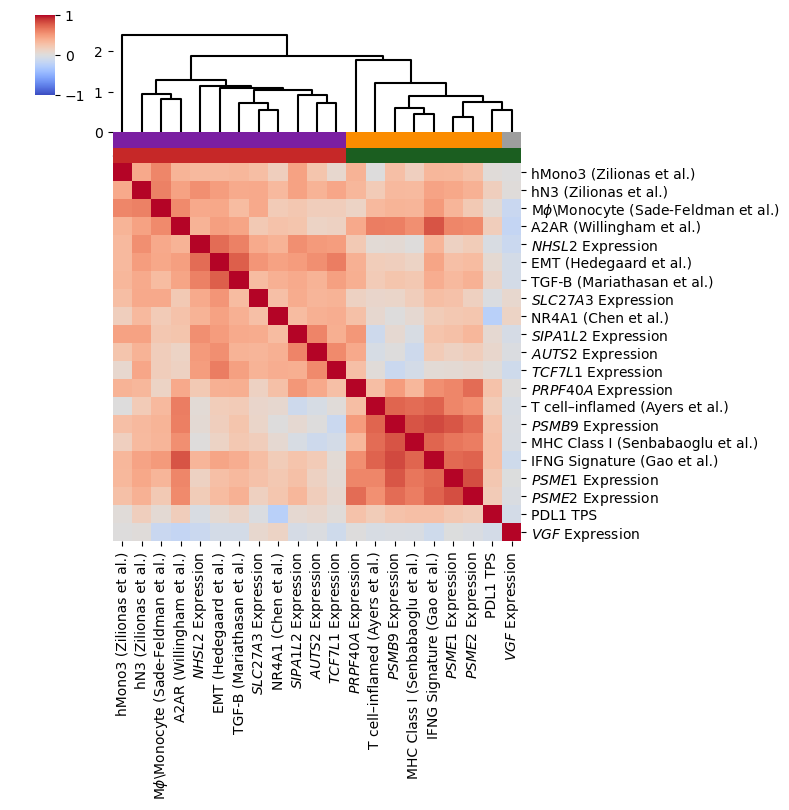

In [309]:
# corr_df is your correlation matrix (DataFrame NxN)
g = plot_corr_heatmap_with_two_layers(
    corr_df=su2c_heatmap_renamed_mine,   # or your corr_df
    rename_map=rename_map,          # optional (pretty labels)
    figsize=(8, 8),
    vmin=-1, vmax=1,
)

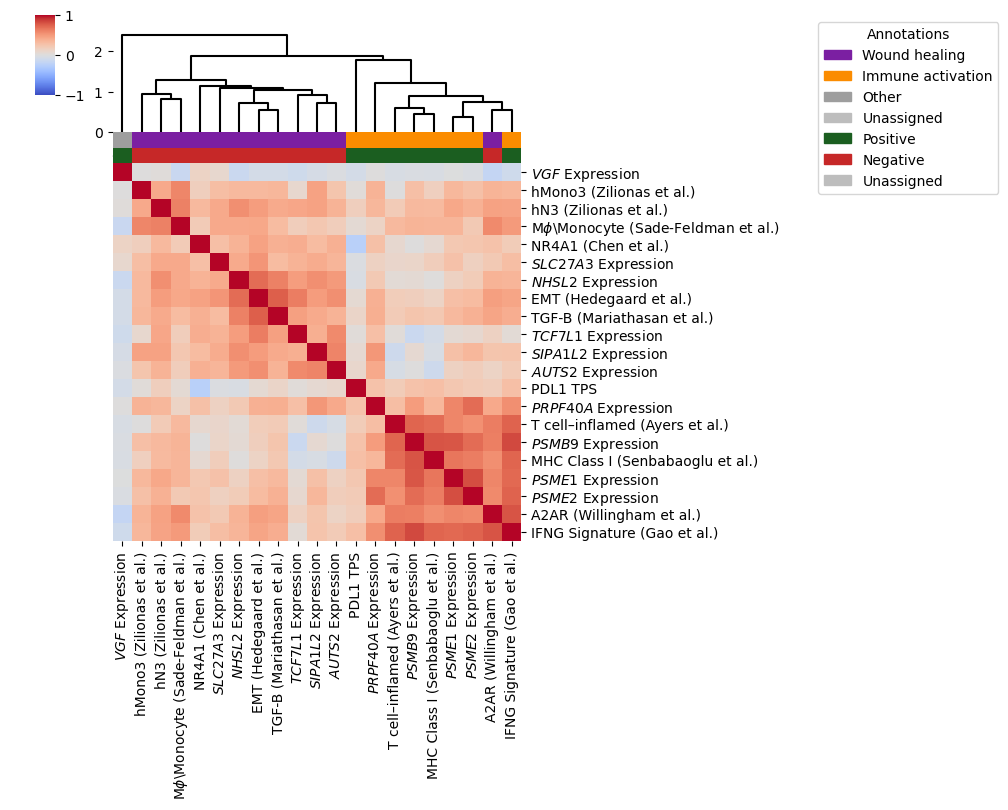

In [314]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# =============================================================================
# INPUT: corr (correlation matrix)
# =============================================================================
# corr = su2c_heatmap_renamed   # <- ví dụ
# corr phải là DataFrame NxN, index == columns

# =============================================================================
# 1) Define groups + pretty label map (optional)
#    IMPORTANT: groups below must match ORIGINAL feature names in corr.columns
# =============================================================================
# ---- OPTIONAL: pretty labels for display ----
rename_map = {
    # Wound healing (examples)
    "hMono3_ZI": "hMono3 (Zilionas et al.)",
    "hN3_ZI": "hN3 (Zilionas et al.)",
    "Macrophages/Monocytes_SF": r"M$\phi$\Monocyte (Sade-Feldman et al.)",
    "Adenosine (Corvus) (Willingham et al.)_HM": "A2AR (Willingham et al.)",
    "NHSL2": r"$\it{NHSL2}$ Expression",
    "EMT2 (PMID: 27321955)_HM": "EMT (Hedegaard et al.)",
    "TGF-B (Mariathasan Nature 2018)_HM": "TGF-B (Mariathasan et al.)",
    "SLC27A3": r"$\it{SLC27A3}$ Expression",
    "NFAT/NR4A1 family T cell dysfunction_HM": "NR4A1 (Chen et al.)",
    "SIPA1L2": r"$\it{SIPA1L2}$ Expression",
    "AUTS2": r"$\it{AUTS2}$ Expression",
    "TCF7L1": r"$\it{TCF7L1}$ Expression",

    # Immune activation
    "PRPF40A": r"$\it{PRPF40A}$ Expression",
    "Merck/Nanostring 18 gene\xa0T cell–inflamed GEP score_HM": "T cell–inflamed (Ayers et al.)",
    "PSMB9": r"$\it{PSMB9}$ Expression",
    "Antigen processing machinery (PMID: 27855702)_HM": "MHC Class I (Senbabaoglu et al.)",
    "IFNG_HM": "IFNG Signature (Gao et al.)",
    "PSME1": r"$\it{PSME1}$ Expression",
    "PSME2": r"$\it{PSME2}$ Expression",
    "PDL1_TPS": "PDL1 TPS",

    # Other
    "VGF": r"$\it{VGF}$ Expression",
}

# ---- Define groups as sets of ORIGINAL feature names (before renaming) ----
wound_healing = {
    "hMono3_ZI", "hN3_ZI", "Macrophages/Monocytes_SF", "Adenosine (Corvus) (Willingham et al.)_HM",
    "NHSL2", "EMT2 (PMID: 27321955)_HM", "TGF-B (Mariathasan Nature 2018)_HM",
    "SLC27A3", "NFAT/NR4A1 family T cell dysfunction_HM", "SIPA1L2",
    "AUTS2", "TCF7L1",
}

immune_activation = {
    "PRPF40A", "Merck/Nanostring 18 gene\xa0T cell–inflamed GEP score_HM", "PSMB9",
    "Antigen processing machinery (PMID: 27855702)_HM", "IFNG_HM",
    "PSME1", "PSME2", "PDL1_TPS",
}

other = {"VGF"}

positive = set(immune_activation) | {"VGF"}  # per your spec
negative = set(wound_healing)                # per your spec


# =============================================================================
# 2) Palettes (the colors you asked for)
# =============================================================================
pal_cat = {
    "Wound healing": "#7B1FA2",      # tím
    "Immune activation": "#FB8C00",  # cam
    "Other": "#9E9E9E",              # xám (tuỳ chọn)
    "Unassigned": "#BDBDBD",
}
pal_assoc = {
    "Positive": "#1B5E20",           # xanh lá đậm
    "Negative": "#C62828",           # đỏ
    "Unassigned": "#BDBDBD",
}


# =============================================================================
# 3) Build 2 color layers (must align with columns of matrix being plotted)
# =============================================================================
def build_color_layers_for_columns(cols: list[str]):
    cat = {}
    assoc = {}

    for c in cols:
        # Category layer
        if c in wound_healing:
            cat[c] = "Wound healing"
        elif c in immune_activation:
            cat[c] = "Immune activation"
        elif c in other:
            cat[c] = "Other"
        else:
            cat[c] = "Unassigned"

        # Association layer
        if c in positive:
            assoc[c] = "Positive"
        elif c in negative:
            assoc[c] = "Negative"
        else:
            assoc[c] = "Unassigned"

    color_layer_category = pd.Series({c: pal_cat[cat[c]] for c in cols}, index=cols, name="Category")
    color_layer_assoc = pd.Series({c: pal_assoc[assoc[c]] for c in cols}, index=cols, name="Association")

    return color_layer_category, color_layer_assoc


# =============================================================================
# 4) Plot function (dendrogram matches heatmap by reordering using dendrogram leaves)
# =============================================================================
def plot_corr_heatmap_with_two_layers(corr: pd.DataFrame,
                                      rename_map = None,
                                      figsize=(15, 15),
                                      vmin=-1, vmax=1,
                                      cmap="coolwarm"):
    # Basic checks
    assert isinstance(corr, pd.DataFrame)
    assert corr.shape[0] == corr.shape[1]
    assert list(corr.index) == list(corr.columns), "corr index must equal corr columns (same order)."

    # --- Work on ORIGINAL names for clustering/order ---
    corr_orig = corr.copy()

    # 1) Make a temporary clustermap to get dendrogram ordering + linkage
    og = sns.clustermap(corr_orig, cmap=cmap, vmin=vmin, vmax=vmax)
    col_order = og.dendrogram_col.reordered_ind
    row_order = og.dendrogram_row.reordered_ind
    link = og.dendrogram_col.linkage
    plt.close(og.fig)

    # 2) Reorder correlation matrix to match dendrogram leaves
    corr_reordered_orig = corr_orig.iloc[row_order, col_order]

    # 3) Create two color layers and reorder them to match corr_reordered_orig columns
    color_layer_category, color_layer_assoc = build_color_layers_for_columns(corr_orig.columns.tolist())
    color_layer_category = color_layer_category.reindex(corr_reordered_orig.columns)
    color_layer_assoc = color_layer_assoc.reindex(corr_reordered_orig.columns)

    # 4) Optional: rename labels for DISPLAY only (after ordering is fixed)
    if rename_map is not None:
        corr_reordered = corr_reordered_orig.rename(index=rename_map, columns=rename_map)
        # Rename color-layer index to match displayed columns
        color_layer_category.index = corr_reordered.columns
        color_layer_assoc.index = corr_reordered.columns
    else:
        corr_reordered = corr_reordered_orig

    # 5) Plot main clustermap WITHOUT clustering (because already ordered)
    g = sns.clustermap(
        corr_reordered,
        cmap=cmap, vmin=vmin, vmax=vmax,
        row_cluster=False, col_cluster=False,
        col_colors=[color_layer_category, color_layer_assoc],
        figsize=figsize,
        xticklabels=True, yticklabels=True
    )

    # 6) Draw dendrogram on top using linkage from ORIGINAL corr
    axx = g.ax_col_dendrogram.axes
    axx.clear()
    from scipy.cluster.hierarchy import dendrogram
    dendrogram(
        link,
        ax=axx,
        orientation="top",
        color_threshold=0,
        link_color_func=lambda x: "k"
    )

    # 7) Colorbar position like notebook (optional)
    g.ax_cbar.set_position((0.05, 0.9, 0.025, 0.1))

    # 8) Legends for two layers
    cat_handles = [mpatches.Patch(color=pal_cat[k], label=k) for k in ["Wound healing", "Immune activation", "Other", "Unassigned"]]
    assoc_handles = [mpatches.Patch(color=pal_assoc[k], label=k) for k in ["Positive", "Negative", "Unassigned"]]

    plt.legend(
        handles=cat_handles + assoc_handles,
        bbox_to_anchor=(1.02, 1),
        bbox_transform=plt.gcf().transFigure,
        loc="upper left",
        title="Annotations",
        frameon=True
    )

    # 9) Tick label formatting
    _ = g.ax_heatmap.set_xticklabels(g.ax_heatmap.get_xmajorticklabels(), fontsize=10)
    _ = g.ax_heatmap.set_yticklabels(g.ax_heatmap.get_ymajorticklabels(), fontsize=10)
    g.ax_heatmap.yaxis.set_label_position("left")

    plt.show()
    return g


# =============================================================================
# RUN
# =============================================================================
g = plot_corr_heatmap_with_two_layers(su2c_heatmap_renamed_mine, rename_map=rename_map,
                                     figsize=(8, 8))

# Survival Curves

## Biomarker Subsets

In [132]:
interaction_list_tmb = ['hMono3_ZI','Macrophages/Monocytes_SF','T1_norm', 'I2_norm','log_TMB_indel',
                              'TERT_CNV','ATM_MUT']
interaction_list_pdl1 = ['hMono3_ZI','Macrophages/Monocytes_SF','T1_norm', 'I2_norm','log_TMB','log_TMB_indel',
                              'TERT_CNV','ATM_MUT']

In [133]:
ls_high_tmb = []

for feature in interaction_list_tmb:
    
    feature_col = feature

    duration_col = 'Harmonized_PFS_Months'
    event_col = 'Harmonized_PFS_Event'

    df = su2c_merge_master[su2c_merge_master['log_TMB']>np.log10(331/33)]

    df_filt = df[[feature_col,duration_col,event_col]].dropna()
    
    if feature_col in ['log_TMB','log_TMB_indel','T1_norm','I2_norm']:
        med = df[feature_col].median()
        df_filt[feature_col] = df_filt[feature_col].apply(lambda x: x>med)
    else:
        df_filt[feature_col] = df_filt[feature_col].apply(lambda x: x>0)
    
    durations = df_filt[duration_col]
    events = df_filt[event_col]
    groups = df_filt[feature_col].astype('category').cat.codes

    results = multivariate_logrank_test(durations,groups,events)

    df_filt_low = df_filt[df_filt[feature_col]==0]
    df_filt_high = df_filt[df_filt[feature_col]==1]

    kmf_exp = KaplanMeierFitter()
    med_pfs_low = kmf_exp.fit(df_filt_low[duration_col],df_filt_low[event_col]).median_survival_time_
    med_pfs_high = kmf_exp.fit(df_filt_high[duration_col],df_filt_high[event_col]).median_survival_time_
    
    ls_high_tmb.append([feature,results.p_value,-np.log10(results.p_value),results.test_statistic,med_pfs_low,med_pfs_high])

In [134]:
df_high_tmb = pd.DataFrame(ls_high_tmb,columns=['feature','p_value','-log10(p_value)','test_stat','med_pfs_low','med_pfs_high'])

In [135]:
ls_pdl1_high = []

for feature in interaction_list_pdl1:
    
    feature_col = feature

    duration_col = 'Harmonized_PFS_Months'
    event_col = 'Harmonized_PFS_Event'

    df = su2c_merge_master[su2c_merge_master['PDL1_TPS']>=0.5]

    df_filt = df[[feature_col,duration_col,event_col]].dropna()

    if feature_col in ['log_TMB','log_TMB_indel','T1_norm','I2_norm']:
        med = df[feature_col].median()
        df_filt[feature_col] = df_filt[feature_col].apply(lambda x: x>med)
    else:
        df_filt[feature_col] = df_filt[feature_col].apply(lambda x: x>0)
    
    durations = df_filt[duration_col]
    events = df_filt[event_col]
    groups = df_filt[feature_col].astype('category').cat.codes

    results = multivariate_logrank_test(durations,groups,events)

    df_filt_low = df_filt[df_filt[feature_col]==0]
    df_filt_high = df_filt[df_filt[feature_col]==1]

    kmf_exp = KaplanMeierFitter()
    med_pfs_low = kmf_exp.fit(df_filt_low[duration_col],df_filt_low[event_col]).median_survival_time_
    med_pfs_high = kmf_exp.fit(df_filt_high[duration_col],df_filt_high[event_col]).median_survival_time_
    
    ls_pdl1_high.append([feature,results.p_value,-np.log10(results.p_value),results.test_statistic,med_pfs_low,med_pfs_high])

In [136]:
df_pdl1_high = pd.DataFrame(ls_pdl1_high,columns=['feature','p_value','-log10(p_value)','test_stat','med_pfs_low','med_pfs_high'])

In [137]:
ls_pdl1_low = []

for feature in interaction_list_pdl1:

    feature_col = feature

    duration_col = 'Harmonized_PFS_Months'
    event_col = 'Harmonized_PFS_Event'

    df = su2c_merge_master[su2c_merge_master['PDL1_TPS']<=0.01]

    df_filt = df[[feature_col,duration_col,event_col]].dropna()

    if feature_col in ['log_TMB','log_TMB_indel','T1_norm','I2_norm']:
        med = df[feature_col].median()
        df_filt[feature_col] = df_filt[feature_col].apply(lambda x: x>med)
    else:
        df_filt[feature_col] = df_filt[feature_col].apply(lambda x: x>0)
    
    durations = df_filt[duration_col]
    events = df_filt[event_col]
    groups = df_filt[feature_col].astype('category').cat.codes

    results = multivariate_logrank_test(durations,groups,events)

    df_filt_low = df_filt[df_filt[feature_col]==0]
    df_filt_high = df_filt[df_filt[feature_col]==1]

    kmf_exp = KaplanMeierFitter()
    med_pfs_low = kmf_exp.fit(df_filt_low[duration_col],df_filt_low[event_col]).median_survival_time_
    med_pfs_high = kmf_exp.fit(df_filt_high[duration_col],df_filt_high[event_col]).median_survival_time_
    
    ls_pdl1_low.append([feature,results.p_value,-np.log10(results.p_value),results.test_statistic,med_pfs_low,med_pfs_high])

In [138]:
df_pdl1_low = pd.DataFrame(ls_pdl1_low,columns=['feature','p_value','-log10(p_value)','test_stat','med_pfs_low','med_pfs_high'])

In [139]:
df_high_tmb['subset'] = 'High TMB'
df_pdl1_high['subset'] = 'High PDL1'
df_pdl1_low['subset'] = 'Low PDL1'

In [140]:
df_subset = pd.concat([df_high_tmb,df_pdl1_high,df_pdl1_low]).dropna(subset=['p_value'])

In [141]:
df_subset['q'] = multi.multipletests(df_subset['p_value'],method='fdr_bh')[1]

In [142]:
df_subset['-log10(q-values)'] = -np.log10(df_subset['q'])

In [143]:
df_subset['favorable'] = df_subset['med_pfs_low']<df_subset['med_pfs_high']

In [144]:
df_subset = df_subset.reset_index().drop('index',axis=1)

In [145]:
for row in range(0,len(df_subset.index)):
    if df_subset.loc[row,'favorable']:
        df_subset.loc[row,'Signed log10(q-value)'] = df_subset.loc[row,'-log10(q-values)']
    else:
        df_subset.loc[row,'Signed log10(q-value)'] = -1*df_subset.loc[row,'-log10(q-values)']

In [146]:
df_subset['cluster'] = '0'
for i in range(0,len(df_subset.index)):
    if df_subset['feature'][i] in ['hMono3_ZI','Macrophages/Monocytes_SF']:
        df_subset.iloc[i,-1] = '1'
    elif df_subset['feature'][i] in ['PDL1_TPS','T1_norm','I2_norm']:
        df_subset.iloc[i,-1] = '2'
    elif df_subset['feature'][i] in ['log_TMB','log_TMB_indel']:
        df_subset.iloc[i,-1] = '3'
    else:
        df_subset.iloc[i,-1] = '4'

In [147]:
df_subset = df_subset.sort_values(by=['subset','cluster'])

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family ['Arial'] not found. Falling back to DejaVu Sans.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Ari

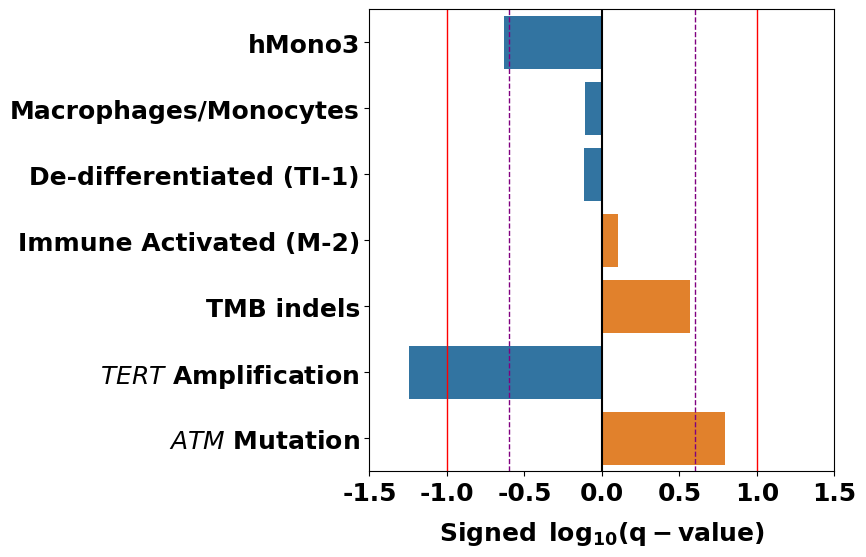

In [148]:
df_plot=df_subset[df_subset['subset']=='High TMB'].sort_values(by='cluster')
plt.figure(figsize=(6,6))
ylabels = ['hMono3','Macrophages/Monocytes','De-differentiated (TI-1)',
           'Immune Activated (M-2)','TMB indels',
           '$\it{TERT}$ Amplification','$\it{ATM}$ Mutation']
h = sns.barplot(y=df_plot['feature'],x=df_plot['Signed log10(q-value)'],orient='h',\
                hue=df_plot['favorable'],dodge=False)
ax=plt.gca()
ymin=ax.get_ylim()[0]
ymax=ax.get_ylim()[1]
plt.vlines(x=0,ymin=ymin,ymax=ymax,colors='k')
ax.axvline(linewidth=1,x=-np.log10(0.1),linestyle='-',c='r')
ax.axvline(linewidth=1,x=-np.log10(0.25),linestyle='dashed',c='purple')
ax.axvline(linewidth=1,x=np.log10(0.1),linestyle='-',c='r')
ax.axvline(linewidth=1,x=np.log10(0.25),linestyle='dashed',c='purple')
plt.ylabel(None)
plt.setp(ax.get_yticklabels(),font = 'Arial',fontsize=18,weight='bold')
plt.setp(ax.get_xticklabels(), fontsize=18)
plt.xlim(-1.5,1.5)
plt.ylim(6.5,-0.5)
h.set_yticklabels(ylabels)
plt.xlabel('$\mathregular{Signed\hspace{0.5}log_{10}(q-value)}$',weight='bold',fontsize=18,labelpad=10)
ax.set_xticklabels(ax.get_xticks(),font='Arial',weight='bold',fontsize=18)
h.legend_.remove()

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

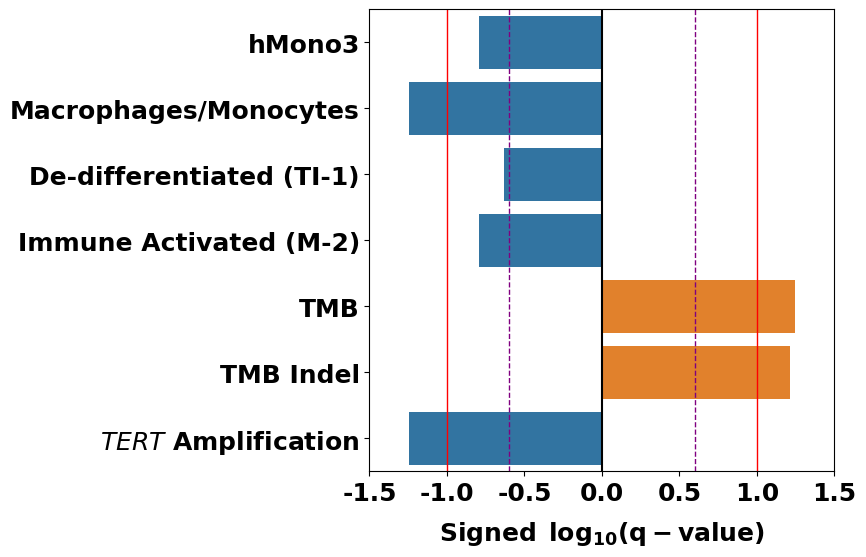

In [149]:
df_plot=df_subset[df_subset['subset']=='High PDL1'].sort_values(by='cluster')
plt.figure(figsize=(6,6))
ylabels = ['hMono3','Macrophages/Monocytes','De-differentiated (TI-1)','Immune Activated (M-2)','TMB','TMB Indel','$\it{TERT}$ Amplification','$\it{ATM}$ Mutation']
h = sns.barplot(y=df_plot['feature'],x=df_plot['Signed log10(q-value)'],orient='h',\
                hue=df_plot['favorable'],dodge=False)
ax=plt.gca()
ymin=ax.get_ylim()[0]
ymax=ax.get_ylim()[1]
plt.vlines(x=0,ymin=ymin,ymax=ymax,colors='k')
ax.axvline(linewidth=1,x=-np.log10(0.1),linestyle='-',c='r')
ax.axvline(linewidth=1,x=-np.log10(0.25),linestyle='dashed',c='purple')
ax.axvline(linewidth=1,x=np.log10(0.1),linestyle='-',c='r')
ax.axvline(linewidth=1,x=np.log10(0.25),linestyle='dashed',c='purple')
plt.ylabel(None)
plt.setp(ax.get_yticklabels(),font = 'Arial',fontsize=18,weight='bold')
plt.setp(ax.get_xticklabels(), fontsize=12)
plt.xlim(-1.5,1.5)
plt.ylim(6.5,-0.5)
h.set_yticklabels(ylabels)    
plt.xlabel('$\mathregular{Signed\hspace{0.5}log_{10}(q-value)}$',weight='bold',fontsize=18,labelpad=10)
ax.set_xticklabels(ax.get_xticks(),font='Arial',weight='bold',fontsize=18)
h.legend_.remove()

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

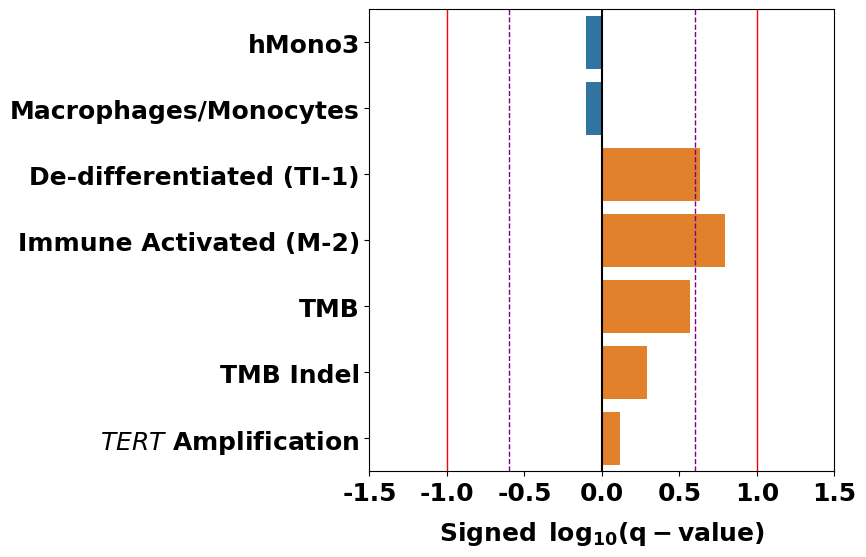

In [150]:
df_plot=df_subset[df_subset['subset']=='Low PDL1'].sort_values(by='cluster')
plt.figure(figsize=(6,6))
ylabels = ['hMono3','Macrophages/Monocytes','De-differentiated (TI-1)','Immune Activated (M-2)','TMB','TMB Indel','$\it{TERT}$ Amplification','$\it{ATM}$ Mutation']
h = sns.barplot(y=df_plot['feature'],x=df_plot['Signed log10(q-value)'],orient='h',\
                hue=df_plot['favorable'],dodge=False)
ax=plt.gca()
ymin=ax.get_ylim()[0]
ymax=ax.get_ylim()[1]
plt.vlines(x=0,ymin=ymin,ymax=ymax,colors='k')
ax.axvline(linewidth=1,x=-np.log10(0.1),linestyle='-',c='r')
ax.axvline(linewidth=1,x=-np.log10(0.25),linestyle='dashed',c='purple')
ax.axvline(linewidth=1,x=np.log10(0.1),linestyle='-',c='r')
ax.axvline(linewidth=1,x=np.log10(0.25),linestyle='dashed',c='purple')
plt.ylabel(None)
plt.setp(ax.get_yticklabels(),font = 'Arial',fontsize=18,weight='bold')
plt.setp(ax.get_xticklabels(), fontsize=12)
plt.xlim(-1.5,1.5)
plt.ylim(6.5,-0.5)
h.set_yticklabels(ylabels)    
plt.xlabel('$\mathregular{Signed\hspace{0.5}log_{10}(q-value)}$',weight='bold',fontsize=18,labelpad=10)
ax.set_xticklabels(ax.get_xticks(),font='Arial',weight='bold',fontsize=18)
h.legend_.remove()

## Biomarker PFS Plots

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

<Figure size 800x400 with 0 Axes>

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

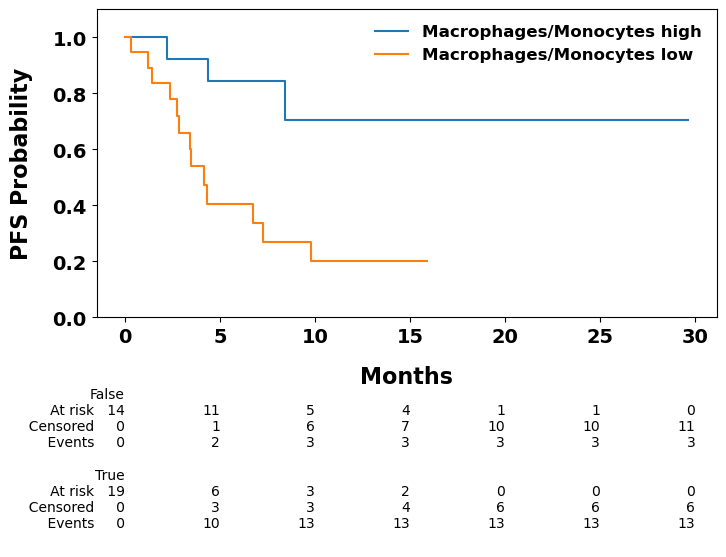

In [316]:
plt.figure(figsize=(8,4))

feature_col = 'Macrophages/Monocytes_SF'
duration_col = 'Harmonized_PFS_Months'
event_col = 'Harmonized_PFS_Event'

df = su2c_merge_master[su2c_merge_master['PDL1_TPS']>=.5]
df_filt = df[[feature_col,duration_col,event_col]].dropna()
df_filt[feature_col] = df_filt[feature_col].apply(lambda x: x>0)

medpfs, ax = survival_curve_pair(df_filt,feature_col,duration_col,event_col)

plt.ylim(0,1.1)
ax.set_ylabel("PFS Probability",font='Arial',weight='bold',fontsize=16,labelpad = 14)
ax.set_xlabel("Months",font='Arial',weight='bold',fontsize=16,labelpad=14)
ax.set_xticklabels(np.round(ax.get_xticks()),font='Arial',weight='bold',fontsize=14)
ax.set_yticklabels(np.round(ax.get_yticks(),1),font='Arial',weight='bold',fontsize=14)
L = ax.legend(frameon=False,prop={'size':12,'weight':'bold'})
L.get_texts()[0].set_text("Macrophages/Monocytes high")
L.get_texts()[1].set_text("Macrophages/Monocytes low")
ax.xaxis.set_major_formatter(FormatStrFormatter('%.0f'))
fig = plt.gcf()
fig.set_size_inches(8, 4)

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

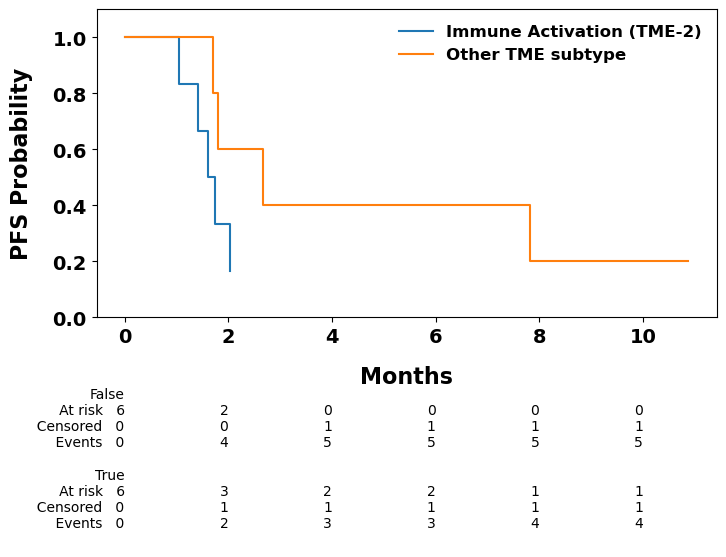

In [152]:
feature_col = 'I2_norm'
duration_col = 'Harmonized_PFS_Months'
event_col = 'Harmonized_PFS_Event'

df = su2c_merge_master[su2c_merge_master['PDL1_TPS']<0.01]
df_filt = df[[feature_col,duration_col,event_col]].dropna()
med = su2c_merge_master[feature_col].median()

df_filt[feature_col] = (df_filt[feature_col]>med)

medpfs, ax = survival_curve_pair(df_filt,feature_col,duration_col,event_col)
plt.ylim(0,1.1)
ax.set_ylabel("PFS Probability",font='Arial',weight='bold',fontsize=16,labelpad = 14)
ax.set_xlabel("Months",font='Arial',weight='bold',fontsize=16,labelpad=14)
ax.set_xticklabels(np.round(ax.get_xticks()),font='Arial',weight='bold',fontsize=14)
ax.set_yticklabels(np.round(ax.get_yticks(),1),font='Arial',weight='bold',fontsize=14)
L = ax.legend(frameon=False,prop={'size':12,'weight':'bold'})
L.get_texts()[0].set_text("Immune Activation (TME-2)")
L.get_texts()[1].set_text("Other TME subtype")
ax.xaxis.set_major_formatter(FormatStrFormatter('%.0f'))
fig = plt.gcf()
fig.set_size_inches(8, 4)

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.


<Figure size 800x400 with 0 Axes>

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

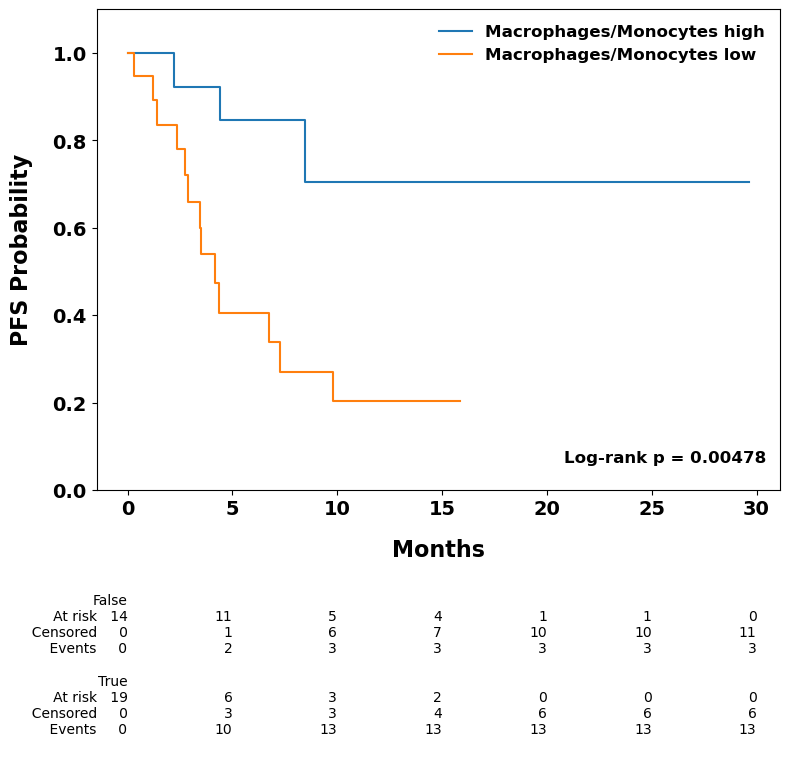

In [320]:
import numpy as np
import matplotlib.pyplot as plt
from lifelines.statistics import logrank_test
from matplotlib.pyplot import FormatStrFormatter

plt.figure(figsize=(8,4))

feature_col = 'Macrophages/Monocytes_SF'
duration_col = 'Harmonized_PFS_Months'
event_col = 'Harmonized_PFS_Event'

df = su2c_merge_master[su2c_merge_master['PDL1_TPS']>=.5]
df_filt = df[[feature_col, duration_col, event_col]].dropna().copy()

# binarize like notebook
df_filt[feature_col] = df_filt[feature_col].apply(lambda x: x > 0)

# plot KM curves (your function)
medpfs, ax = survival_curve_pair(df_filt, feature_col, duration_col, event_col)

# ---- ADD: log-rank p-value ----
df_low = df_filt[df_filt[feature_col] == False]
df_high = df_filt[df_filt[feature_col] == True]

results = logrank_test(
    df_high[duration_col], df_low[duration_col],
    event_observed_A=df_high[event_col],
    event_observed_B=df_low[event_col],
)

pval = results.p_value

# annotate on plot (top-right)
ax.text(
    0.98, 0.05,
    f'Log-rank p = {pval:.3g}',
    transform=ax.transAxes,
    ha='right', va='bottom',
    fontsize=12, fontweight='bold', fontname='Arial'
)

# formatting (your original)
plt.ylim(0,1.1)
ax.set_ylabel("PFS Probability", font='Arial', weight='bold', fontsize=16, labelpad=14)
ax.set_xlabel("Months", font='Arial', weight='bold', fontsize=16, labelpad=14)
ax.set_xticklabels(np.round(ax.get_xticks()), font='Arial', weight='bold', fontsize=14)
ax.set_yticklabels(np.round(ax.get_yticks(),1), font='Arial', weight='bold', fontsize=14)

L = ax.legend(frameon=False, prop={'size':12,'weight':'bold'})
L.get_texts()[0].set_text("Macrophages/Monocytes high")
L.get_texts()[1].set_text("Macrophages/Monocytes low")

ax.xaxis.set_major_formatter(FormatStrFormatter('%.0f'))
fig = plt.gcf()
fig.set_size_inches(8, 8)

plt.tight_layout()
plt.show()